In [1]:
import json
import math
import sys
import time
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

In [3]:
from scipy.optimize import brentq
from scipy.stats import chi2, poisson

In [4]:
from matplotlib.patches import Arc, Rectangle

print("Pitch drawing tools loaded.")

Pitch drawing tools loaded.


In [5]:
COMPETITION_ID = 1267
SEASON_ID = 107
FOCUS_TEAM = "Nigeria"
RIVAL_TEAM = "Côte d'Ivoire"

In [6]:
MIN_MINUTES = 500   
TOP_N = 15 
EXCLUDE_PENALTIES_FROM_FINISHING = True
ALPHA_OUTER = 0.05
ALPHA_INNER = 0.002

In [7]:
BASE_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

HERE = Path.cwd()

RAW_DIR = HERE / "data_raw"
OUT_DIR = HERE / "outputs"
CHART_DIR = OUT_DIR / "charts"

In [8]:

GREEN = "#008751"   # Nigeria
ORANGE = "#F77F00"  # Cote d'Ivoire
GREY = "#6b7280"
DARK = "#111827"
LIGHT = "#d1d5db"

In [9]:
print("Working directory:", HERE)
print("Raw data folder:", RAW_DIR)
print("Output folder:", OUT_DIR)
print("Charts folder:", CHART_DIR)

Working directory: /Users/mack
Raw data folder: /Users/mack/data_raw
Output folder: /Users/mack/outputs
Charts folder: /Users/mack/outputs/charts


In [10]:
def ensure_dirs():
    for d in (RAW_DIR, OUT_DIR, CHART_DIR):
        d.mkdir(parents=True, exist_ok=True)

In [11]:
def poisson_ci(k, alpha=0.05):
    """Exact (Garwood) confidence interval for a Poisson count k. Returns (lower, upper)."""
    k = np.asarray(k, dtype=float)
    safe_df = 2.0 * np.where(k > 0, k, 1.0)
    lower = np.where(k > 0, chi2.ppf(alpha / 2.0, safe_df) / 2.0, 0.0)
    upper = chi2.ppf(1.0 - alpha / 2.0, 2.0 * (k + 1.0)) / 2.0
    return lower, upper

In [12]:
def funnel_high(expected, alpha):
    """Observed count above which a unit is significantly HIGH versus `expected` (continuous curve)."""
    f = lambda o: chi2.ppf(alpha / 2.0, 2.0 * o) / 2.0 - expected
    return brentq(f, 1e-9, expected + 10.0 * math.sqrt(expected) + 20.0)



In [13]:

def funnel_low(expected, alpha):
    """Observed count below which a unit is significantly LOW versus `expected` (continuous curve)."""
    g = lambda o: chi2.ppf(1.0 - alpha / 2.0, 2.0 * (o + 1.0)) / 2.0 - expected
    if g(0.0) >= 0:
        return 0.0
    return brentq(g, 0.0, expected)




In [14]:
def classify_vs_expected(observed, expected):
    """Plain-English verdict from the funnel limits."""
    if expected <= 0:
        return "no expected value"
    hi_inner, hi_outer = funnel_high(expected, ALPHA_INNER), funnel_high(expected, ALPHA_OUTER)
    lo_inner, lo_outer = funnel_low(expected, ALPHA_INNER), funnel_low(expected, ALPHA_OUTER)
    if observed > hi_inner:
        return "well above expected (outside 99.8%)"
    if observed > hi_outer:
        return "above expected (outside 95%)"
    if observed < lo_inner:
        return "well below expected (outside 99.8%)"
    if observed < lo_outer:
        return "below expected (outside 95%)"
    return "consistent with chance"

In [15]:
def add_ratio_columns(df, obs_col, exp_col, prefix="sfr"):
    """Adds observed/expected ratio, exact 95% CI and verdict."""
    df = df.copy()
    lo, hi = poisson_ci(df[obs_col].values, ALPHA_OUTER)
    exp = df[exp_col].replace(0, np.nan)
    df[prefix] = df[obs_col] / exp
    df[f"{prefix}_ci_low"] = lo / exp
    df[f"{prefix}_ci_high"] = hi / exp
    df["verdict"] = [
        classify_vs_expected(o, e) if e > 0 else "no expected value"
        for o, e in zip(df[obs_col], df[exp_col])
    ]
    return df




In [16]:
def rate_with_ci(counts, minutes, alpha=0.05):
    """Per-90 rate with exact Poisson CI, treating minutes played as the exposure."""
    counts = np.asarray(counts, dtype=float)
    exposure = np.asarray(minutes, dtype=float) / 90.0
    exposure = np.where(exposure > 0, exposure, np.nan)
    lo, hi = poisson_ci(counts, alpha)
    return counts / exposure, lo / exposure, hi / exposure




In [17]:
def match_probabilities(mu_a, mu_b, max_goals=12):
    """Win/draw/loss probabilities for side A from two independent Poisson goal rates."""
    goals = np.arange(max_goals + 1)
    joint = np.outer(
        poisson.pmf(goals, mu_a),
        poisson.pmf(goals, mu_b)
    )

    return (
        np.tril(joint, -1).sum(),
        np.trace(joint),
        np.triu(joint, 1).sum()
    )


def funnel_curve(max_expected):
    """Funnel control-limit curves (as ratios to expected) for plotting and Power BI."""

    grid = np.round(
        np.linspace(
            0.1,
            max(max_expected * 1.1, 1.0),
            120
        ),
        4
    )

    rows = []

    for e in grid:
        rows.append(
            {
                "expected": e,
                "low_95": funnel_low(e, ALPHA_OUTER) / e,
                "high_95": funnel_high(e, ALPHA_OUTER) / e,
                "low_998": funnel_low(e, ALPHA_INNER) / e,
                "high_998": funnel_high(e, ALPHA_INNER) / e
            }
        )

    return pd.DataFrame(rows)


In [18]:
def funnel_curve(max_expected):

    """Funnel control-limit curves (as ratios to expected) for plotting and Power BI."""

    grid = np.round(np.linspace(0.1, max(max_expected * 1.1, 1.0), 120), 4)

    rows = []

    for e in grid:

        rows.append(

            {

                "expected": e,

                "low_95": funnel_low(e, ALPHA_OUTER) / e,

                "high_95": funnel_high(e, ALPHA_OUTER) / e,

                "low_998": funnel_low(e, ALPHA_INNER) / e,

                "high_998": funnel_high(e, ALPHA_INNER) / e

            }

        )

    return pd.DataFrame(rows)

In [19]:
#download#

In [20]:
_session = requests.Session()


def fetch_json(rel_path, retries=4):
    local = RAW_DIR / rel_path
    if local.exists():
        with open(local, "r", encoding="utf-8") as fh:
            return json.load(fh)
    local.parent.mkdir(parents=True, exist_ok=True)
    url = f"{BASE_URL}/{rel_path}"
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            resp = _session.get(url, timeout=60)
            if resp.status_code == 200:
                data = resp.json()
                with open(local, "w", encoding="utf-8") as fh:
                    json.dump(data, fh)
                time.sleep(0.1)  # be polite to GitHub
                return data
            last_err = f"HTTP {resp.status_code}"
        except requests.RequestException as exc:  # network hiccup
            last_err = str(exc)
        time.sleep(1.5 * attempt)
    raise RuntimeError(f"Could not download {url}: {last_err}")


def fold(text):
    """Accent-insensitive lowercase key, so 'Cote d'Ivoire' matches 'Côte d'Ivoire'."""
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode().lower()


In [21]:
#Load#

In [22]:
def clock_to_min(text):
    """'63:12' -> 63.2 (the match clock keeps counting through extra time)."""
    if text is None:
        return None
    mm, ss = text.split(":")[:2]
    return int(mm) + int(ss) / 60.0




In [23]:
def ts_to_min(text):
    """'00:47:19.510' (time inside one period) -> 47.32 minutes."""
    hh, mm, ss = text.split(":")
    return int(hh) * 60 + int(mm) + float(ss) / 60.0


# The StatsBomb match clock restarts each period at a nominal value (0, 45, 90, 105), so stoppage time
# at the end of a period overlaps with the start of the next one. To count minutes honestly we convert
# every clock reading to real ELAPSED playing time using each period's true length from the events.
NOMINAL_START = {1: 0.0, 2: 45.0, 3: 90.0, 4: 105.0}
NOMINAL_END = {1: 45.0, 2: 90.0, 3: 105.0, 4: 120.0}


def period_starts(period_dur):
    """Elapsed minutes at which each period begins, e.g. {1: 0, 2: 47.3, ...}."""
    starts, total = {}, 0.0
    for p in (1, 2, 3, 4):
        starts[p] = total
        total += period_dur.get(p, NOMINAL_END[p] - NOMINAL_START[p])
    return starts


def clock_to_elapsed(clock_min, period, period_dur, as_end=False):
    """Convert a lineup clock reading in a given period to elapsed playing time."""
    starts = period_starts(period_dur)
    period = period if period in starts else 4
    if as_end and abs(clock_min - NOMINAL_END[period]) < 0.01:
        return starts[period] + period_dur.get(period, NOMINAL_END[period] - NOMINAL_START[period])
    return starts[period] + (clock_min - NOMINAL_START[period])


In [24]:
DEPARTURE_PREFIXES = ("Substitution - Off", "Player Off", "Foul Committed (Second Yellow)", "Foul Committed (Red Card)")
ENTRY_PREFIXES = ("Starting XI", "Player On", "Substitution - On")


DEFENSIVE_MAP = {
    "Pressure": "pressures",
    "Interception": "interceptions",
    "Block": "blocks",
    "Clearance": "clearances",
    "Ball Recovery": "recoveries",
}


def load_matches():
    raw = fetch_json(f"matches/{COMPETITION_ID}/{SEASON_ID}.json")
    rows = []
    for m in raw:
        rows.append(
            {
                "match_id": m["match_id"],
                "match_date": m["match_date"],
                "kick_off": m.get("kick_off"),
                "stage": m["competition_stage"]["name"],
                "match_week": m.get("match_week"),
                "home_team_id": m["home_team"]["home_team_id"],
                "home_team": m["home_team"]["home_team_name"],
                "away_team_id": m["away_team"]["away_team_id"],
                "away_team": m["away_team"]["away_team_name"],
                "home_score": m["home_score"],
                "away_score": m["away_score"],
                "stadium": (m.get("stadium") or {}).get("name", "").strip(),
                "match_status": m.get("match_status"),
            }
        )
    df = pd.DataFrame(rows).sort_values(["match_date", "kick_off", "match_id"]).reset_index(drop=True)
    return df



In [25]:
def parse_events(match_id, events):
    """Pulls shots, key passes, defensive actions, own goals and the match end time from one match."""
    shots, key_passes, defensive, own_goals = [], [], [], []
    field_counter = Counter()
    period_dur = {}
    max_period = 1
    max_clock = 0.0
    shootout_shots = 0
    shootout_seen = False

    for ev in events:
        field_counter.update(ev.keys())
        period = ev.get("period", 0)
        etype = ev["type"]["name"]
        if period >= 5:  # penalty shootout: separate, excluded from everything
            shootout_seen = True
            if etype == "Shot":
                shootout_shots += 1
            continue
        clock = ev.get("minute", 0) + ev.get("second", 0) / 60.0
        max_clock = max(max_clock, clock)
        max_period = max(max_period, period)
        if etype == "Half End" and ev.get("timestamp"):
            period_dur[period] = max(period_dur.get(period, 0.0), ts_to_min(ev["timestamp"]))

        player = ev.get("player") or {}
        team = ev.get("team") or {}

        if etype == "Shot":
            sh = ev["shot"]
            loc = ev.get("location") or [np.nan, np.nan]
            shots.append(
                {
                    "match_id": match_id,
                    "shot_id": ev["id"],
                    "event_index": ev["index"],
                    "period": period,
                    "minute": ev.get("minute"),
                    "second": ev.get("second"),
                    "clock": clock,
                    "ts_min": ts_to_min(ev.get("timestamp") or "00:00:00.000"),
                    "team_id": team.get("id"),
                    "team": team.get("name"),
                    "player_id": player.get("id"),
                    "player": player.get("name"),
                    "position": (ev.get("position") or {}).get("name"),
                    "x": loc[0],
                    "y": loc[1],
                    "xg": sh.get("statsbomb_xg"),
                    "outcome": sh["outcome"]["name"],
                    "body_part": (sh.get("body_part") or {}).get("name"),
                    "shot_type": (sh.get("type") or {}).get("name"),
                    "technique": (sh.get("technique") or {}).get("name"),
                    "first_time": bool(sh.get("first_time", False)),
                    "under_pressure": bool(ev.get("under_pressure", False)),
                    "play_pattern": (ev.get("play_pattern") or {}).get("name"),
                }
            )
        elif etype == "Own Goal For":
            own_goals.append({"match_id": match_id, "team_id": team.get("id"), "clock": clock})
        elif etype == "Pass":
            p = ev.get("pass") or {}
            if p.get("shot_assist") or p.get("goal_assist"):
                key_passes.append(
                    {
                        "match_id": match_id,
                        "player_id": player.get("id"),
                        "team_id": team.get("id"),
                        "goal_assist": bool(p.get("goal_assist", False)),
                    }
                )
        elif etype in DEFENSIVE_MAP:
            defensive.append({"match_id": match_id, "player_id": player.get("id"), "action": DEFENSIVE_MAP[etype]})
        elif etype == "Duel" and ((ev.get("duel") or {}).get("type") or {}).get("name") == "Tackle":
            defensive.append({"match_id": match_id, "player_id": player.get("id"), "action": "tackles"})

    # real elapsed playing time of every shot (period start + time inside the period)
    starts = period_starts(period_dur)
    for s in shots:
        s["elapsed"] = starts.get(s["period"], 0.0) + s["ts_min"]
    match_end = sum(period_dur.get(p, 0.0) for p in range(1, max_period + 1) if p <= 4) or max_clock
    return {
        "shots": shots,
        "key_passes": key_passes,
        "defensive": defensive,
        "own_goals": own_goals,
        "match_end": match_end,
        "period_dur": period_dur,
        "max_period": min(max_period, 4),
        "shootout": shootout_seen,
        "shootout_shots": shootout_shots,
        "fields": field_counter,
    }



In [26]:
def parse_lineups(match_id, lineups, period_dur, match_end):
    """Minutes played per player in real elapsed time.

    A player's time on the pitch runs from their earliest segment start to their first genuine departure
    (substitution off, injury, red card or second yellow), otherwise to the end of the match. StatsBomb's
    'Tactical Shift' segments can overlap and even run to the final whistle for players already
    substituted off, so segments are never simply added together.
    """
    rows = []
    for team_block in lineups:
        for pl in team_block["lineup"]:
            segments = pl.get("positions") or []
            if not segments:
                continue  # unused substitute

            def seg_bounds(seg):
                fp = seg.get("from_period") or 1
                s = clock_to_elapsed(clock_to_min(seg.get("from")) or NOMINAL_START.get(fp, 0.0), fp, period_dur)
                if seg.get("to") is None:
                    e = match_end
                else:
                    tp = seg.get("to_period") or fp
                    e = clock_to_elapsed(clock_to_min(seg["to"]), tp, period_dur, as_end=True)
                return s, min(e, match_end)

            bounds = [seg_bounds(s) for s in segments]
            # On/off state machine. 'Player Off' followed by 'Player On' is a short injury break, so a
            # player can have several spells. 'Tactical Shift' segments are only position changes and never
            # count as an entry or an exit. An entry while the player is already on the pitch is a
            # duplicate record and is ignored; an exit while he is already off is ignored too.
            events = []  # (elapsed minute, 1 = entry / 0 = exit, reason)
            for seg, (s, e) in zip(segments, bounds):
                sr, er = seg.get("start_reason") or "", seg.get("end_reason") or ""
                if sr.startswith(ENTRY_PREFIXES):
                    events.append((s, 1, sr))
                if seg.get("to") is not None and er.startswith(DEPARTURE_PREFIXES):
                    events.append((e, 0, er))
            events.sort(key=lambda t: (t[0], t[1]))  # exits before entries at the same instant
            if not events or events[0][1] == 0:  # no explicit entry record before the first exit
                implicit = min(b[0] for b in bounds)
                events.insert(0, (implicit, 1, "Implicit entry"))
                IMPLICIT_ENTRIES.append(
                    f"match {match_id}: {pl.get('player_nickname') or pl['player_name']} ({team_block['team_name']}) has no "
                    f"explicit entry record; assumed on the pitch from elapsed {implicit:.1f} min"
                )
            merged, on_since, on_reason = [], None, None
            for t, kind, rsn in events:
                if kind == 1:
                    if on_since is None and t < match_end:
                        on_since, on_reason = t, rsn
                elif on_since is not None:
                    if t > on_since:
                        merged.append((on_since, t, on_reason))
                    on_since = None
            if on_since is not None:
                merged.append((on_since, match_end, on_reason))
            total = sum(max(0.0, e - s) for s, e, _ in merged)

            pos_minutes = defaultdict(float)
            for seg, (s, e) in zip(segments, bounds):
                for ps, pe, _ in merged:
                    pos_minutes[seg.get("position", "Unknown")] += max(0.0, min(e, pe) - max(s, ps))
            started = any(s.get("start_reason") == "Starting XI" for s in segments)
            primary_pos = max(pos_minutes, key=pos_minutes.get) if pos_minutes else None
            rows.append(
                {
                    "match_id": match_id,
                    "team_id": team_block["team_id"],
                    "team": team_block["team_name"],
                    "player_id": pl["player_id"],
                    "player": pl.get("player_nickname") or pl["player_name"],
                    "player_full_name": pl["player_name"],
                    "jersey_number": pl.get("jersey_number"),
                    "started": started,
                    "minutes": total,
                    "position": primary_pos,
                    "_spells": merged,
                }
            )
    return rows


In [27]:
LINEUP_NOTES = []      # lineup conflicts that were auto-resolved (check these against the match reports)
IMPLICIT_ENTRIES = []  # players with no explicit 'on the pitch' record (mostly half-time substitutes)


def enforce_eleven(match_id, rows):
    """Never allow more than 11 players per team on the pitch at once.

    StatsBomb lineups occasionally show an injured player as 'Player On' again at the same moment his
    replacement comes on. When that would put a 12th player on the pitch, the returning player's spell is
    dropped (the substitute took his place). Every case is logged so it can be checked against the match.
    """
    by_team = defaultdict(list)
    for r in rows:
        by_team[r["team_id"]].append(r)
    rejected = set()
    for plist in by_team.values():
        timeline = []
        for r in plist:
            for i, (s, e, rsn) in enumerate(r["_spells"]):
                if e - s <= 1e-9:
                    continue
                timeline.append((round(s, 6), 1, 1 if rsn.startswith("Player On") else 0, r, i))
                timeline.append((round(e, 6), 0, 0, r, i))
        # at the same instant: exits first, then ordinary entries, then returns from a break
        timeline.sort(key=lambda t: (t[0], t[1], t[2]))
        on = 0
        for time_, is_entry, is_return, r, i in timeline:
            key = (r["player_id"], i)
            if is_entry:
                if on >= 11 and is_return:
                    rejected.add(key)
                    LINEUP_NOTES.append(
                        f"match {match_id}: ignored {r['player']}'s return ('Player On') at elapsed {time_:.1f} min "
                        f"for {r['team']} because 11 players were already on the pitch"
                    )
                else:
                    if on >= 11:
                        LINEUP_NOTES.append(
                            f"match {match_id}: {r['team']} shows {on + 1} players on the pitch at elapsed {time_:.1f} min "
                            f"({r['player']} entering); could not be resolved automatically"
                        )
                    on += 1
            elif key not in rejected:
                on -= 1
    for r in rows:
        kept = [sp for i, sp in enumerate(r.pop("_spells")) if (r["player_id"], i) not in rejected]
        r["minutes"] = sum(max(0.0, e - s) for s, e, _ in kept)
    return rows

In [28]:
def build_tables():
    print("\n[1/6] Downloading and parsing data (cached after the first run)")
    dim_match = load_matches()
    dim_match = dim_match[dim_match["match_status"] == "available"].reset_index(drop=True)
    n_matches = len(dim_match)
    print(f"  {n_matches} matches available")

    all_shots, all_kp, all_def, all_og, all_min = [], [], [], [], []
    match_meta = {}
    field_counter = Counter()
    total_shootout_shots = 0

    for i, mid in enumerate(dim_match["match_id"], start=1):
        events = fetch_json(f"events/{mid}.json")
        lineups = fetch_json(f"lineups/{mid}.json")
        parsed = parse_events(mid, events)
        field_counter.update(parsed["fields"])
        total_shootout_shots += parsed["shootout_shots"]
        match_meta[mid] = {
            "match_end": parsed["match_end"], "shootout": parsed["shootout"],
            "max_period": parsed["max_period"], "period_dur": parsed["period_dur"],
        }
        all_shots += parsed["shots"]
        all_kp += parsed["key_passes"]
        all_def += parsed["defensive"]
        all_og += parsed["own_goals"]
        all_min += enforce_eleven(mid, parse_lineups(mid, lineups, parsed["period_dur"], parsed["match_end"]))
        if i % 10 == 0 or i == n_matches:
            print(f"  processed {i}/{n_matches} matches")

    dim_match["match_end_min"] = dim_match["match_id"].map(lambda m: match_meta[m]["match_end"])
    dim_match["went_to_shootout"] = dim_match["match_id"].map(lambda m: match_meta[m]["shootout"])
    dim_match["went_to_extra_time"] = dim_match["match_id"].map(lambda m: match_meta[m]["max_period"] >= 3)
    for p in (1, 2, 3, 4):
        dim_match[f"period{p}_min"] = dim_match["match_id"].map(lambda m: match_meta[m]["period_dur"].get(p, np.nan))

    shots = pd.DataFrame(all_shots)
    key_passes = pd.DataFrame(all_kp)
    defensive = pd.DataFrame(all_def)
    own_goals = pd.DataFrame(all_og)
    minutes = pd.DataFrame(all_min)

    # derived shot columns
    shots["is_goal"] = (shots["outcome"] == "Goal").astype(int)
    shots["is_penalty"] = (shots["shot_type"] == "Penalty").astype(int)
    shots["xg"] = shots["xg"].astype(float)
    shots["y_flipped"] = 80.0 - shots["y"]  # for Power BI scatter (y up)
    shots = shots.drop(columns=["ts_min"]).sort_values(["match_id", "event_index"]).reset_index(drop=True)
    shots["cum_xg_team_match"] = shots.groupby(["match_id", "team_id"])["xg"].cumsum()
    shots["cum_goals_team_match"] = shots.groupby(["match_id", "team_id"])["is_goal"].cumsum()
    opp_lookup = {}
    for _, m in dim_match.iterrows():
        opp_lookup[(m["match_id"], m["home_team_id"])] = m["away_team"]
        opp_lookup[(m["match_id"], m["away_team_id"])] = m["home_team"]
    shots["opponent"] = [opp_lookup[(a, b)] for a, b in zip(shots["match_id"], shots["team_id"])]

    return dim_match, shots, key_passes, defensive, own_goals, minutes, field_counter, total_shootout_shots


In [29]:
#Fact and dimension tables#

In [30]:
def build_facts(dim_match, shots, key_passes, defensive, own_goals, minutes):
    print("\n[2/6] Building fact and dimension tables")

    # ---- dim_team
    teams = pd.concat(
        [
            dim_match[["home_team_id", "home_team"]].rename(columns={"home_team_id": "team_id", "home_team": "team"}),
            dim_match[["away_team_id", "away_team"]].rename(columns={"away_team_id": "team_id", "away_team": "team"}),
        ]
    ).drop_duplicates()
    dim_team = teams.sort_values("team").reset_index(drop=True)
    dim_team["is_focus_team"] = (dim_team["team"].map(fold) == fold(FOCUS_TEAM)).astype(int)

    # ---- fact_player_match
    fpm = minutes.copy()
    fpm = fpm.drop_duplicates(["match_id", "player_id"])

    def agg_shots(frame, suffix=""):
        g = frame.groupby(["match_id", "player_id"]).agg(
            shots=("shot_id", "count"),
            goals=("is_goal", "sum"),
            xg=("xg", "sum"),
        )
        g.columns = [c + suffix for c in g.columns]
        return g

    np_shots = shots[shots["is_penalty"] == 0]
    shot_agg = agg_shots(shots).join(agg_shots(np_shots, "_np"), how="outer").reset_index()
    fpm = fpm.merge(shot_agg, on=["match_id", "player_id"], how="left")

    if len(key_passes):
        kp = key_passes.groupby(["match_id", "player_id"]).agg(
            key_passes=("player_id", "count"), assists=("goal_assist", "sum")
        ).reset_index()
        fpm = fpm.merge(kp, on=["match_id", "player_id"], how="left")
    else:
        fpm["key_passes"], fpm["assists"] = 0, 0

    for col in DEFENSIVE_MAP.values():
        fpm[col] = 0
    fpm["tackles"] = 0
    if len(defensive):
        dpiv = defensive.pivot_table(index=["match_id", "player_id"], columns="action", aggfunc="size", fill_value=0).reset_index()
        fpm = fpm.drop(columns=[c for c in dpiv.columns if c in fpm.columns and c not in ("match_id", "player_id")])
        fpm = fpm.merge(dpiv, on=["match_id", "player_id"], how="left")
        for col in list(DEFENSIVE_MAP.values()) + ["tackles"]:
            if col not in fpm.columns:
                fpm[col] = 0
    num_cols = [c for c in fpm.columns if c not in ("player", "player_full_name", "team", "position", "started", "jersey_number")]
    fpm[num_cols] = fpm[num_cols].fillna(0)
    fpm["started"] = fpm["started"].astype(int)

    # shooters not in lineups (should not happen) are flagged by the checks later
    # ---- dim_player
    dim_player = (
        fpm.sort_values("minutes", ascending=False)
        .groupby("player_id")
        .agg(
            player=("player", "first"),
            player_full_name=("player_full_name", "first"),
            team_id=("team_id", "first"),
            team=("team", "first"),
            primary_position=("position", "first"),
            jersey_number=("jersey_number", "first"),
        )
        .reset_index()
    )

    # ---- fact_team_match (two rows per match)
    rows = []
    for _, m in dim_match.iterrows():
        rows.append(
            {
                "match_id": m["match_id"], "team_id": m["home_team_id"], "team": m["home_team"],
                "opp_id": m["away_team_id"], "opponent": m["away_team"], "is_home": 1,
                "goals_scoreline": m["home_score"], "goals_conceded_scoreline": m["away_score"],
            }
        )
        rows.append(
            {
                "match_id": m["match_id"], "team_id": m["away_team_id"], "team": m["away_team"],
                "opp_id": m["home_team_id"], "opponent": m["home_team"], "is_home": 0,
                "goals_scoreline": m["away_score"], "goals_conceded_scoreline": m["home_score"],
            }
        )
    ftm = pd.DataFrame(rows)

    team_agg = shots.groupby(["match_id", "team_id"]).agg(
        shots=("shot_id", "count"),
        shot_goals=("is_goal", "sum"),
        xg=("xg", "sum"),
    ).reset_index()
    team_agg_np = np_shots.groupby(["match_id", "team_id"]).agg(
        np_shots=("shot_id", "count"), np_goals=("is_goal", "sum"), npxg=("xg", "sum")
    ).reset_index()
    og = own_goals.groupby(["match_id", "team_id"]).size().rename("own_goals_for").reset_index() if len(own_goals) else pd.DataFrame(columns=["match_id", "team_id", "own_goals_for"])

    ftm = ftm.merge(team_agg, on=["match_id", "team_id"], how="left").merge(team_agg_np, on=["match_id", "team_id"], how="left").merge(og, on=["match_id", "team_id"], how="left")
    for col in ["shots", "shot_goals", "xg", "np_shots", "np_goals", "npxg", "own_goals_for"]:
        ftm[col] = ftm[col].fillna(0)
    ftm["goals_for"] = ftm["shot_goals"] + ftm["own_goals_for"]

    against = ftm[["match_id", "team_id", "shots", "xg", "npxg", "goals_for"]].rename(
        columns={"team_id": "opp_id", "shots": "shots_against", "xg": "xg_against", "npxg": "npxg_against", "goals_for": "goals_against"}
    )
    ftm = ftm.merge(against, on=["match_id", "opp_id"], how="left")
    ftm = ftm.merge(dim_match[["match_id", "match_date", "stage", "went_to_shootout", "went_to_extra_time"]], on="match_id", how="left")
    ftm["goal_diff"] = ftm["goals_for"] - ftm["goals_against"]
    ftm["xg_diff"] = ftm["xg"] - ftm["xg_against"]
    ftm["points"] = np.where(ftm["goals_for"] > ftm["goals_against"], 3, np.where(ftm["goals_for"] == ftm["goals_against"], 1, 0))

    # expected points from xG totals (independent Poisson)
    xp = []
    for _, r in ftm.iterrows():
        pw, pdw, _pl = match_probabilities(r["xg"], r["xg_against"])
        xp.append((pw, pdw, 3 * pw + pdw))
    ftm["p_win_from_xg"], ftm["p_draw_from_xg"], ftm["expected_points"] = zip(*xp)

    return dim_team, dim_player, fpm, ftm



In [31]:
#Quality check#

In [32]:
class Checks:
    def __init__(self):
        self.rows = []

    def add(self, name, ok, detail="", critical=True):
        self.rows.append((name, bool(ok), detail, critical))
        flag = "PASS" if ok else ("FAIL" if critical else "WARN")
        print(f"  [{flag}] {name}" + (f" - {detail}" if detail else ""))

    def write(self, path):
        lines = ["QUALITY REPORT", "=" * 60]
        for name, ok, detail, critical in self.rows:
            flag = "PASS" if ok else ("FAIL" if critical else "WARN")
            lines.append(f"[{flag}] {name}" + (f" - {detail}" if detail else ""))
        Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")

    @property
    def failed(self):
        return [r for r in self.rows if not r[1] and r[3]]


CHECKS = Checks()

In [33]:
def run_checks(dim_match, shots, fpm, ftm, total_shootout_shots):
    print("\n[3/6] Quality checks")
    # statistics unit tests
    lo, hi = poisson_ci(10)
    CHECKS.add("Poisson CI for k=10 matches published exact limits (4.80, 18.39)", abs(lo - 4.795) < 0.01 and abs(hi - 18.390) < 0.01, f"got ({float(lo):.3f}, {float(hi):.3f})")
    lo0, hi0 = poisson_ci(0)
    CHECKS.add("Poisson CI for k=0 is (0, 3.69)", float(lo0) == 0.0 and abs(float(hi0) - 3.689) < 0.01, f"got ({float(lo0):.3f}, {float(hi0):.3f})")
    CHECKS.add("Funnel high limit sits above the expected value", funnel_high(2.0, 0.05) > 2.0)

    # data checks
    CHECKS.add("Every match has two team rows", ftm.groupby("match_id").size().eq(2).all())
    mismatch = ftm[ftm["goals_for"] != ftm["goals_scoreline"]]
    CHECKS.add(
        "Goals (shots + own goals) reconcile with the official scoreline in every match",
        mismatch.empty,
        "all match" if mismatch.empty else f"{len(mismatch)} team-matches differ: " + ", ".join(f"{r.team} v {r.opponent} ({r.goals_for:.0f} vs {r.goals_scoreline})" for r in mismatch.itertuples()),
    )
    CHECKS.add("Shot ids are unique", shots["shot_id"].is_unique)
    CHECKS.add("Every shot has a player and an xG value", shots["player_id"].notna().all() and shots["xg"].notna().all())
    CHECKS.add("xG values lie between 0 and 1", shots["xg"].between(0, 1).all())
    CHECKS.add("No negative minutes", (fpm["minutes"] >= 0).all())
    over = fpm.merge(dim_match[["match_id", "match_end_min"]], on="match_id")
    CHECKS.add("No player has more minutes than the match lasted", (over["minutes"] <= over["match_end_min"] + 0.5).all())
    team_min = fpm.groupby(["match_id", "team_id"])["minutes"].sum().reset_index().merge(dim_match[["match_id", "match_end_min"]], on="match_id")
    ratio = team_min["minutes"] / (11 * team_min["match_end_min"])
    CHECKS.add("Team minutes never exceed 11 x match length", (ratio <= 1.001).all(), f"max {ratio.max():.3f}")
    CHECKS.add("Team minutes are at least 85% of 11 x match length (red cards and injury breaks reduce it)", (ratio >= 0.85).all(), f"min {ratio.min():.3f}", critical=False)
    CHECKS.add(
        "Lineup conflicts (more than 11 on the pitch) auto-resolved",
        not LINEUP_NOTES,
        "none" if not LINEUP_NOTES else f"{len(LINEUP_NOTES)} case(s), listed in lineup_notes.txt: " + " | ".join(LINEUP_NOTES),
        critical=False,
    )
    CHECKS.add(
        "Players with no explicit entry record (assumed on from first segment)",
        True,
        f"{len(IMPLICIT_ENTRIES)} player-matches, mostly half-time substitutes; listed in lineup_notes.txt",
        critical=False,
    )
    shooters_missing = set(shots["player_id"]) - set(fpm["player_id"])
    CHECKS.add("Every shooter appears in the lineups", not shooters_missing, f"{len(shooters_missing)} missing" if shooters_missing else "", critical=False)
    CHECKS.add("Penalty shootout shots excluded from all analysis", True, f"{total_shootout_shots} shootout shots dropped")
    CHECKS.add("Focus team found in the data", any(fold(t) == fold(FOCUS_TEAM) for t in ftm["team"].unique()))
    CHECKS.add(f"{len(dim_match)} matches loaded", len(dim_match) > 0)



In [34]:
#Analysis questions#

In [35]:
def analysis_q1(dim_match, shots, ftm, dim_team):
    focus_id = dim_team.loc[dim_team["team"].map(fold) == fold(FOCUS_TEAM), "team_id"].iloc[0]
    rival_id = dim_team.loc[dim_team["team"].map(fold) == fold(RIVAL_TEAM), "team_id"].iloc[0]
    pair = dim_match[
        ((dim_match["home_team_id"] == focus_id) & (dim_match["away_team_id"] == rival_id))
        | ((dim_match["home_team_id"] == rival_id) & (dim_match["away_team_id"] == focus_id))
    ].sort_values("match_date")
    q1_ids = pair["match_id"].tolist()
    q1 = ftm[ftm["match_id"].isin(q1_ids)].copy()
    q1["xg_per_shot"] = q1["xg"] / q1["shots"].replace(0, np.nan)
    q1["np_xg_per_shot"] = q1["npxg"] / q1["np_shots"].replace(0, np.nan)
    cols = ["match_id", "match_date", "stage", "team", "opponent", "goals_for", "goals_against", "shots", "xg", "npxg", "xg_against", "npxg_against", "shots_against", "xg_per_shot", "xg_diff", "expected_points", "points", "went_to_shootout"]
    return q1[cols].sort_values(["match_date", "team"]).reset_index(drop=True), q1_ids



In [36]:
#Question 2

In [37]:
def analysis_q2(ftm):
    """Team finishing: non-penalty goals vs non-penalty xG over the tournament."""
    gcol, xcol = ("np_goals", "npxg") if EXCLUDE_PENALTIES_FROM_FINISHING else ("shot_goals", "xg")
    t = ftm.groupby(["team_id", "team"]).agg(
        matches=("match_id", "nunique"),
        shots=("np_shots" if EXCLUDE_PENALTIES_FROM_FINISHING else "shots", "sum"),
        goals=(gcol, "sum"),
        xg=(xcol, "sum"),
    ).reset_index()
    t = add_ratio_columns(t, "goals", "xg")
    t["goals_minus_xg"] = t["goals"] - t["xg"]
    return t.sort_values("sfr", ascending=False).reset_index(drop=True)



In [38]:
def analysis_players(fpm, dim_player):
    """Player totals, finishing (Q3) and per-90 rates (Q4), plus an extra defensive-count table."""
    agg = fpm.groupby("player_id").agg(
        matches=("match_id", "nunique"),
        starts=("started", "sum"),
        minutes=("minutes", "sum"),
        shots_np=("shots_np", "sum"),
        goals_np=("goals_np", "sum"),
        npxg=("xg_np", "sum"),
        shots_all=("shots", "sum"),
        goals_all=("goals", "sum"),
        xg_all=("xg", "sum"),
        key_passes=("key_passes", "sum"),
        assists=("assists", "sum"),
        pressures=("pressures", "sum"),
        tackles=("tackles", "sum"),
        interceptions=("interceptions", "sum"),
        blocks=("blocks", "sum"),
        clearances=("clearances", "sum"),
        recoveries=("recoveries", "sum"),
    ).reset_index()
    players = dim_player.merge(agg, on="player_id", how="inner")
    players["sufficient_exposure"] = (players["minutes"] >= MIN_MINUTES).astype(int)
    return players, finishing_table(players), involvement_table(players), defensive_table(players)

    

In [39]:
def finishing_table(players):
    """Q3: goals vs expected goals per player, with exact intervals and a verdict."""

    gcol, xcol, scol = (
        ("goals_np", "npxg", "shots_np")
        if EXCLUDE_PENALTIES_FROM_FINISHING
        else ("goals_all", "xg_all", "shots_all")
    )

    fin = players[players[xcol] > 0].copy()

    fin = fin.rename(
        columns={
            gcol: "goals",
            xcol: "xg",
            scol: "shots"
        }
    )

    fin = add_ratio_columns(fin, "goals", "xg")

    fin["goals_minus_xg"] = fin["goals"] - fin["xg"]

    low = fin["sufficient_exposure"] == 0

    fin.loc[low, "verdict"] = fin.loc[low, "verdict"].map(
        lambda v: v + " [low minutes]"
    )

    fin_cols = [
        "player_id",
        "player",
        "team",
        "primary_position",
        "minutes",
        "shots",
        "goals",
        "xg",
        "goals_minus_xg",
        "sfr",
        "sfr_ci_low",
        "sfr_ci_high",
        "verdict",
        "sufficient_exposure"
    ]

    return (
        fin[fin_cols]
        .sort_values("xg", ascending=False)
        .reset_index(drop=True)
    )

In [40]:
def involvement_table(players):
    """Q4: shot involvement per 90 (own non-penalty shots + key passes)."""

    rates = players[players["minutes"] > 0].copy()

    rates["involvements"] = rates["shots_np"] + rates["key_passes"]

    for label, col in [
        ("shots_np", "shots_np"),
        ("key_passes", "key_passes"),
        ("involvement", "involvements")
    ]:
        r, lo, hi = rate_with_ci(rates[col], rates["minutes"])

        rates[f"{label}_p90"] = r
        rates[f"{label}_p90_ci_low"] = lo
        rates[f"{label}_p90_ci_high"] = hi

    rates["npxg_p90"] = rates["npxg"] / (rates["minutes"] / 90.0)

    rate_cols = [
        "player_id",
        "player",
        "team",
        "primary_position",
        "minutes",
        "sufficient_exposure",
        "shots_np_p90",
        "shots_np_p90_ci_low",
        "shots_np_p90_ci_high",
        "key_passes_p90",
        "key_passes_p90_ci_low",
        "key_passes_p90_ci_high",
        "involvement_p90",
        "involvement_p90_ci_low",
        "involvement_p90_ci_high",
        "npxg_p90"
    ]

    return (
        rates[rate_cols]
        .sort_values("involvement_p90", ascending=False)
        .reset_index(drop=True)
    )

In [41]:
def defensive_table(players):
    """Extra: simple defensive counts per 90. NOT StatsBomb's DefR / DefR OBV models (those are not used here)."""

    dfn = players[players["minutes"] > 0].copy()

    dfn["def_actions"] = dfn[
        [
            "tackles",
            "interceptions",
            "blocks",
            "clearances",
            "recoveries"
        ]
    ].sum(axis=1)

    r, lo, hi = rate_with_ci(
        dfn["def_actions"],
        dfn["minutes"]
    )

    dfn["def_actions_p90"] = r
    dfn["def_actions_p90_ci_low"] = lo
    dfn["def_actions_p90_ci_high"] = hi

    dfn["pressures_p90"] = dfn["pressures"] / (dfn["minutes"] / 90.0)

    dfn_cols = [
        "player_id",
        "player",
        "team",
        "primary_position",
        "minutes",
        "sufficient_exposure",
        "def_actions_p90",
        "def_actions_p90_ci_low",
        "def_actions_p90_ci_high",
        "pressures_p90"
    ]

    return (
        dfn[dfn_cols]
        .sort_values("def_actions_p90", ascending=False)
        .reset_index(drop=True)
    )

In [42]:
def analysis_q5(ftm):
    """Nigeria's run: results versus what the chances say, plus the tournament-wide 'luck' table."""
    nga = ftm[ftm["team"].map(fold) == fold(FOCUS_TEAM)].sort_values("match_date").copy()
    nga["goal_diff_minus_xg_diff"] = nga["goal_diff"] - nga["xg_diff"]
    nga_cols = ["match_id", "match_date", "stage", "opponent", "goals_for", "goals_against", "xg", "xg_against", "goal_diff", "xg_diff", "goal_diff_minus_xg_diff", "points", "expected_points", "went_to_shootout"]
    nga = nga[nga_cols].reset_index(drop=True)

    luck = ftm.groupby(["team_id", "team"]).agg(
        matches=("match_id", "nunique"),
        goals_for=("goals_for", "sum"), goals_against=("goals_against", "sum"),
        xg_for=("xg", "sum"), xg_against=("xg_against", "sum"),
    ).reset_index()
    luck["goal_diff"] = luck["goals_for"] - luck["goals_against"]
    luck["xg_diff"] = luck["xg_for"] - luck["xg_against"]
    luck["goal_diff_minus_xg_diff"] = luck["goal_diff"] - luck["xg_diff"]
    group = ftm[ftm["stage"] == "Group Stage"].groupby("team_id").agg(group_points=("points", "sum"), group_expected_points=("expected_points", "sum")).reset_index()
    luck = luck.merge(group, on="team_id", how="left")
    luck["group_points_minus_expected"] = luck["group_points"] - luck["group_expected_points"]
    luck = luck.sort_values("goal_diff_minus_xg_diff", ascending=False).reset_index(drop=True)
    return nga, luck


In [43]:
#Charts

In [44]:
def apply_style():
    plt.rcParams.update(
        {
            "font.size": 10,
            "axes.edgecolor": LIGHT,
            "axes.labelcolor": DARK,
            "text.color": DARK,
            "xtick.color": GREY,
            "ytick.color": GREY,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "figure.dpi": 130,
            "savefig.dpi": 200,
            "axes.titleweight": "bold",
            "axes.titlesize": 11,
        }
    )


In [45]:
def team_color(name):
    f = fold(name)

    if f == fold(FOCUS_TEAM):
        return GREEN

    if f == fold(RIVAL_TEAM):
        return ORANGE

    return GREY

In [46]:
def footer(fig, note=None):
    fig.text(
        0.01,
        0.005,
        CREDIT,
        fontsize=7.5,
        color=GREY,
        ha="left",
        va="bottom"
    )

    if note:
        fig.text(
            0.99,
            0.005,
            note,
            fontsize=7.5,
            color=GREY,
            ha="right",
            va="bottom"
        )



In [47]:
def titles(fig, title, subtitle=None):
    """Title on top, subtitle underneath (matplotlib's own title would sit under the subtitle)."""

    fig.text(
        0.012,
        0.978,
        title,
        fontsize=13,
        fontweight="bold",
        ha="left",
        va="top",
        color=DARK
    )

    if subtitle:
        fig.text(
            0.012,
            0.936,
            subtitle,
            fontsize=9,
            color=GREY,
            ha="left",
            va="top"
        )

In [48]:
def draw_half_pitch(ax):
    """Attacking half of a StatsBomb 120 x 80 pitch, y axis inverted (y=0 is the top)."""

    line = dict(
        fill=False,
        edgecolor=LIGHT,
        linewidth=1.2
    )

    ax.add_patch(Rectangle((60, 0), 60, 80, **line))
    ax.add_patch(Rectangle((102, 18), 18, 44, **line))
    ax.add_patch(Rectangle((114, 30), 6, 20, **line))
    ax.add_patch(Rectangle((120, 36), 1.5, 8, **line))

    ax.add_patch(
        Arc(
            (108, 40),
            20,
            20,
            theta1=128,
            theta2=232,
            color=LIGHT,
            linewidth=1.2
        )
    )

    ax.add_patch(
        Arc(
            (60, 40),
            20,
            20,
            theta1=270,
            theta2=90,
            color=LIGHT,
            linewidth=1.2
        )
    )

    ax.plot(
        [108],
        [40],
        marker="o",
        markersize=2,
        color=LIGHT
    )

    ax.set_xlim(58, 122)
    ax.set_ylim(81, -1)
    ax.set_aspect("equal")
    ax.axis("off")


In [49]:
def chart_xg_timeline(shots, dim_match, q1_ids, path):
    fig, axes = plt.subplots(
        1,
        len(q1_ids),
        figsize=(6.2 * len(q1_ids), 4.6),
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for ax, mid in zip(axes, q1_ids):
        m = dim_match[
            dim_match["match_id"] == mid
        ].iloc[0]

        end = m["match_end_min"]

        ms = shots[
            shots["match_id"] == mid
        ]

        for team in (
            m["home_team"],
            m["away_team"]
        ):
            ts = ms[
                ms["team"] == team
            ].sort_values("event_index")

            x = (
                [0.0]
                + ts["elapsed"].tolist()
                + [end]
            )

            y = (
                [0.0]
                + ts["cum_xg_team_match"].tolist()
                + [ts["xg"].sum()]
            )

            ax.step(
                x,
                y,
                where="post",
                color=team_color(team),
                linewidth=2.2,
                label=f"{team}  xG {ts['xg'].sum():.2f}"
            )

            goals = ts[
                ts["is_goal"] == 1
            ]

            ax.scatter(
                goals["elapsed"],
                goals["cum_xg_team_match"],
                s=70,
                color=team_color(team),
                edgecolor="white",
                zorder=5,
                marker="o"
            )

            for _, g in goals.iterrows():
                ax.annotate(
                    f"{int(g['minute'])}'",
                    (
                        g["elapsed"],
                        g["cum_xg_team_match"]
                    ),
                    xytext=(4, 6),
                    textcoords="offset points",
                    fontsize=8,
                    color=team_color(team)
                )

        boundary = 0.0

        for p in (1, 2, 3, 4):
            dur = m.get(f"period{p}_min")

            if pd.isna(dur):
                break

            boundary += dur

            if boundary < end - 0.5:
                ax.axvline(
                    boundary,
                    color=LIGHT,
                    linewidth=0.8,
                    linestyle=":"
                )

        ax.set_title(
            f"{m['stage']}: "
            f"{m['home_team']} "
            f"{m['home_score']}-"
            f"{m['away_score']} "
            f"{m['away_team']}",
            loc="left"
        )

        ax.set_xlabel(
            "Elapsed playing time, minutes "
            "(labels show the official match minute)"
        )

        ax.legend(
            frameon=False,
            loc="upper left",
            fontsize=9
        )

    axes[0].set_ylabel(
        "Cumulative expected goals (dots = goals)"
    )

    fig.suptitle(
        f"{FOCUS_TEAM} vs {RIVAL_TEAM}: what the chances said",
        x=0.01,
        ha="left",
        fontsize=13,
        fontweight="bold"
    )

    footer(
        fig,
        "xG includes penalties here"
    )

    fig.tight_layout(
        rect=(0, 0.03, 1, 0.94)
    )

    fig.savefig(path)

    plt.close(fig)




In [50]:
def chart_shot_maps(shots, dim_match, q1_ids, path):
    n = len(q1_ids)

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(11, 4.4 * n)
    )

    axes = np.atleast_2d(axes)

    for r, mid in enumerate(q1_ids):
        m = dim_match[
            dim_match["match_id"] == mid
        ].iloc[0]

        pair = [
            m["home_team"],
            m["away_team"]
        ]

        pair.sort(
            key=lambda t:
            0 if fold(t) == fold(FOCUS_TEAM) else 1
        )

        for c, team in enumerate(pair):
            ax = axes[r, c]

            draw_half_pitch(ax)

            ts = shots[
                (shots["match_id"] == mid)
                & (shots["team"] == team)
            ]

            miss = ts[
                ts["is_goal"] == 0
            ]

            goals = ts[
                ts["is_goal"] == 1
            ]

            ax.scatter(
                miss["x"],
                miss["y"],
                s=miss["xg"] * 900 + 12,
                color=team_color(team),
                alpha=0.45,
                edgecolor="white",
                linewidth=0.8
            )

            ax.scatter(
                goals["x"],
                goals["y"],
                s=goals["xg"] * 900 + 60,
                color=team_color(team),
                edgecolor=DARK,
                linewidth=1.4,
                marker="*",
                zorder=5
            )

            ax.set_title(
                f"{team}  |  "
                f"{len(ts)} shots, "
                f"xG {ts['xg'].sum():.2f}, "
                f"goals {int(ts['is_goal'].sum())}",
                loc="left",
                fontsize=10
            )

        axes[r, 0].text(
            58,
            -6.5,
            f"{m['stage']}: "
            f"{m['home_team']} "
            f"{m['home_score']}-"
            f"{m['away_score']} "
            f"{m['away_team']}",
            fontsize=10,
            fontweight="bold",
            color=DARK
        )

    fig.suptitle(
        "Shot maps "
        "(bubble size = xG, star = goal, each team attacks right)",
        x=0.01,
        ha="left",
        fontsize=13,
        fontweight="bold"
    )

    footer(fig)

    fig.tight_layout(
        rect=(0, 0.02, 1, 0.95)
    )

    fig.savefig(path)

    plt.close(fig)

In [51]:
def chart_funnel(
    df,
    label_col,
    title,
    subtitle,
    path,
    curve,
    ymax=4.0,
    label_all_focus=True
):
    fig, ax = plt.subplots(
        figsize=(8.6, 6.0)
    )

    ax.fill_between(
        curve["expected"],
        curve["low_95"],
        curve["high_95"],
        color="#e5e7eb",
        alpha=0.8
    )

    ax.plot(
        curve["expected"],
        curve["high_998"],
        color=GREY,
        linestyle="--",
        linewidth=1,
        label="99.8% limits"
    )

    ax.plot(
        curve["expected"],
        curve["low_998"],
        color=GREY,
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        1.0,
        color=DARK,
        linewidth=1
    )

    for _, r in df.iterrows():
        y = r["sfr"]

        clipped = y > ymax

        y_plot = min(y, ymax)

        color = team_color(r["team"])

        outside = "outside" in r["verdict"]

        ax.scatter(
            r["xg"],
            y_plot,
            s=60 if outside else 38,
            color=color,
            edgecolor=DARK if outside else "white",
            linewidth=1 if outside else 0.8,
            zorder=4
        )

        is_focus = fold(r["team"]) in (
            fold(FOCUS_TEAM),
        )

        if outside or (
            label_all_focus
            and is_focus
        ):
            ax.annotate(
                r[label_col],
                (r["xg"], y_plot),
                xytext=(6, -13 if clipped else 5),
                textcoords="offset points",
                fontsize=8
            )

    ax.set_ylim(
        0,
        ymax
    )

    ax.set_xlim(
        0,
        curve["expected"].max()
    )

    ax.set_xlabel(
        "Expected goals "
        "(the more chances, the narrower the funnel)"
    )

    ax.set_ylabel(
        "Goals / expected goals "
        "(1.0 = exactly as expected)"
    )

    titles(
        fig,
        title,
        subtitle
    )

    ax.legend(
        frameon=False,
        loc="upper right",
        fontsize=8
    )

    footer(
        fig,
        "Penalties excluded"
        if EXCLUDE_PENALTIES_FROM_FINISHING
        else ""
    )

    fig.tight_layout(
        rect=(0, 0.03, 1, 0.89)
    )

    fig.savefig(path)

    plt.close(fig)

In [52]:
def chart_forest(fin, path):
    top = (
        fin.sort_values("xg", ascending=False)
        .head(TOP_N)
        .iloc[::-1]
    )

    fig, ax = plt.subplots(
        figsize=(8.6, 0.42 * len(top) + 2.2)
    )

    xmax = 4.0

    for i, (_, r) in enumerate(top.iterrows()):
        color = team_color(r["team"])

        hi = min(
            r["sfr_ci_high"],
            xmax
        )

        ax.plot(
            [r["sfr_ci_low"], hi],
            [i, i],
            color=color,
            linewidth=2,
            alpha=0.8
        )

        if r["sfr_ci_high"] > xmax:
            ax.annotate(
                "",
                xy=(xmax, i),
                xytext=(xmax - 0.15, i),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color
                )
            )

        ax.scatter(
            min(r["sfr"], xmax),
            i,
            s=48,
            color=color,
            edgecolor="white",
            zorder=4
        )

    ax.axvline(
        1.0,
        color=DARK,
        linewidth=1
    )

    ax.set_yticks(
        range(len(top))
    )

    ax.set_yticklabels(
        [
            f"{p} ({t}, {x:.1f} xG)"
            for p, t, x in zip(
                top["player"],
                top["team"],
                top["xg"]
            )
        ]
    )

    ax.set_xlim(
        0,
        xmax
    )

    ax.set_xlabel(
        "Goals / expected goals with exact 95% interval "
        "(1.0 = as expected)"
    )

    titles(
        fig,
        "Finishing: how much is skill and how much is noise?",
        f"Top {len(top)} players by non-penalty xG. "
        "Intervals that cross 1.0 cannot be told apart from average finishing."
    )

    footer(fig)

    fig.tight_layout(
        rect=(0, 0.03, 1, 0.91)
    )

    fig.savefig(path)

    plt.close(fig)


In [53]:
def chart_involvement(rates, path):
    pool = (
        rates[
            rates["sufficient_exposure"] == 1
        ]
        .sort_values(
            "involvement_p90",
            ascending=False
        )
        .head(TOP_N)
        .iloc[::-1]
    )

    fig, ax = plt.subplots(
        figsize=(8.6, 0.42 * len(pool) + 2.2)
    )

    for i, (_, r) in enumerate(pool.iterrows()):
        color = team_color(r["team"])

        ax.plot(
            [
                r["involvement_p90_ci_low"],
                r["involvement_p90_ci_high"]
            ],
            [i, i],
            color=color,
            linewidth=2,
            alpha=0.8
        )

        ax.scatter(
            r["involvement_p90"],
            i,
            s=48,
            color=color,
            edgecolor="white",
            zorder=4
        )

    ax.set_yticks(
        range(len(pool))
    )

    ax.set_yticklabels(
        [
            f"{p} ({t}, {int(m)} min)"
            for p, t, m in zip(
                pool["player"],
                pool["team"],
                pool["minutes"]
            )
        ],
        fontsize=8
    )

    ax.set_xlabel(
        "Non-penalty shots + key passes per 90 minutes, exact 95% interval"
    )

    titles(
        fig,
        "Who is most involved in creating shots?",
        f"Players with at least {MIN_MINUTES} minutes. "
        "Overlapping intervals mean the ranking is not settled."
    )

    footer(fig)

    fig.tight_layout(
        rect=(0, 0.03, 1, 0.91)
    )

    fig.savefig(path)

    plt.close(fig)


In [54]:
def chart_nigeria_run(nga, path):
    fig, ax = plt.subplots(
        figsize=(9.2, 5.0)
    )

    x = np.arange(
        len(nga)
    )

    w = 0.38

    ax.bar(
        x - w / 2,
        nga["goal_diff"],
        w,
        color=GREEN,
        label="Actual goal difference"
    )

    ax.bar(
        x + w / 2,
        nga["xg_diff"],
        w,
        color=LIGHT,
        edgecolor=GREEN,
        label="xG difference (what the chances said)"
    )

    ax.axhline(
        0,
        color=DARK,
        linewidth=1
    )

    labels = [
        f"{r.opponent}\n{r.stage.replace(' Stage', '')}"
        for r in nga.itertuples()
    ]

    ax.set_xticks(x)

    ax.set_xticklabels(
        labels,
        fontsize=8
    )

    ax.set_ylabel(
        "Goal difference for Nigeria"
    )

    titles(
        fig,
        f"{FOCUS_TEAM}: results versus chances",
        f"Total goal difference "
        f"{nga['goal_diff'].sum():+.0f} vs xG difference "
        f"{nga['xg_diff'].sum():+.2f}. Shootouts excluded."
    )

    ax.legend(
        frameon=False,
        fontsize=9
    )

    footer(fig)

    fig.tight_layout(
        rect=(0, 0.03, 1, 0.89)
    )

    fig.savefig(path)

    plt.close(fig)

In [55]:
#Output

In [56]:
def save(df, name, round_to=4):
    path = OUT_DIR / name

    out = df.copy()

    for col in out.select_dtypes(include=[float]).columns:
        out[col] = out[col].round(round_to)

    out.to_csv(
        path,
        index=False,
        encoding="utf-8-sig"
    )

    return path


In [57]:
def write_field_audit(field_counter, path):
    """Is any StatsBomb model output (e.g. OBV or DefR) present in the free event files?"""

    names = sorted(field_counter)

    suspicious = [
        n
        for n in names
        if any(
            k in n.lower()
            for k in ("obv", "defr", "responsibility")
        )
    ]

    lines = [
        "EVENT FIELD AUDIT (top-level keys across all AFCON 2023 events)",
        "=" * 60,
        f"Distinct keys: {len(names)}",
        "Keys containing obv / defr / responsibility: "
        + (
            ", ".join(suspicious)
            if suspicious
            else "none"
        ),
        "",
    ] + [
        f"{n}: {field_counter[n]}"
        for n in names
    ]

    Path(path).write_text(
        "\n".join(lines) + "\n",
        encoding="utf-8"
    )

    print(
        "  OBV/DefR-style fields in the free event files: "
        + (
            ", ".join(suspicious)
            if suspicious
            else "none"
        )
    )

    return suspicious


In [58]:
def write_lineup_notes(path):
    notes = [
        "LINEUP NOTES (StatsBomb lineup files contain a few inconsistent records)",
        "=" * 70,
        "A. Conflicts auto-resolved (verify against match reports):"
    ]

    notes += [
        "  " + n
        for n in LINEUP_NOTES
    ] or ["  none"]

    notes += [
        "",
        "B. Players with no explicit entry record "
        "(assumed on from first segment):"
    ]

    notes += [
        "  " + n
        for n in IMPLICIT_ENTRIES
    ] or ["  none"]

    Path(path).write_text(
        "\n".join(notes) + "\n",
        encoding="utf-8"
    )


In [59]:
def write_outputs(
    dim_match,
    dim_team,
    dim_player,
    shots,
    fpm,
    ftm,
    results,
    curves,
    field_counter
):
    print(
        "\n[5/6] Writing CSV tables for Power BI -> outputs/"
    )

    save(dim_match, "dim_match.csv")
    save(dim_team, "dim_team.csv")
    save(dim_player, "dim_player.csv")
    save(shots, "fact_shot.csv")
    save(fpm, "fact_player_minutes.csv")
    save(ftm, "fact_team_match.csv")

    save(
        results["q1"],
        "q1_nigeria_vs_rival.csv"
    )

    save(
        results["team_fin"],
        "q2_team_finishing.csv"
    )

    save(
        results["player_fin"],
        "q3_player_finishing.csv"
    )

    save(
        results["rates"],
        "q4_player_shot_involvement_p90.csv"
    )

    save(
        results["nga_run"],
        "q5_nigeria_run.csv"
    )

    save(
        results["luck"],
        "q5_team_luck_table.csv"
    )

    save(
        curves["teams"],
        "funnel_curve_teams.csv"
    )

    save(
        curves["players"],
        "funnel_curve_players.csv"
    )

    save(
        results["def_extra"],
        "extra_player_defensive_counts_p90.csv"
    )

    write_field_audit(
        field_counter,
        OUT_DIR / "event_field_audit.txt"
    )

    CHECKS.write(
        OUT_DIR / "quality_report.txt"
    )

    write_lineup_notes(
        OUT_DIR / "lineup_notes.txt"
    )

In [60]:
def draw_charts(dim_match, shots, results, curves):
    print(
        "\n[6/6] Drawing charts -> outputs/charts/"
    )

    apply_style()

    chart_xg_timeline(
        shots,
        dim_match,
        results["q1_ids"],
        CHART_DIR / "01_nigeria_vs_rival_xg_timeline.png"
    )

    chart_shot_maps(
        shots,
        dim_match,
        results["q1_ids"],
        CHART_DIR / "02_nigeria_vs_rival_shot_maps.png"
    )

    chart_funnel(
        results["team_fin"],
        "team",
        "Which teams beat or missed their chances by most?",
        "Each dot is a team's finishing over the whole tournament. "
        "Inside the funnel = consistent with chance alone.",
        CHART_DIR / "03_team_finishing_funnel.png",
        curves["teams"],
        ymax=3.0
    )

    pf = results["player_fin"].rename(
        columns={"player": "label"}
    )

    chart_funnel(
        pf,
        "label",
        "Which players' finishing is real signal, and which is noise?",
        "Each dot is a player. Most sit inside the funnel: "
        "too few shots to call the difference from average finishing.",
        CHART_DIR / "04_player_finishing_funnel.png",
        curves["players"],
        ymax=5.0,
        label_all_focus=True
    )

    chart_forest(
        results["player_fin"],
        CHART_DIR / "05_top_players_finishing_forest.png"
    )

    chart_involvement(
        results["rates"],
        CHART_DIR / "06_shot_involvement_per90.png"
    )

    chart_nigeria_run(
        results["nga_run"],
        CHART_DIR / "07_nigeria_results_vs_chances.png"
    )

In [61]:
def print_headlines(results):
    q1 = results["q1"]
    team_fin = results["team_fin"]
    player_fin = results["player_fin"]

    rates = results["rates"]
    nga_run = results["nga_run"]

    print("\n" + "=" * 70)

    print(
        "HEADLINE NUMBERS "
        "(check these against the charts before you post)"
    )

    print("=" * 70)

    print("\nQ1 Nigeria vs Cote d'Ivoire")

    print(
        q1[
            [
                "stage",
                "team",
                "goals_for",
                "shots",
                "xg",
                "npxg",
                "xg_against",
                "npxg_against"
            ]
        ]
    )

    print(
        " (xg includes penalties; npxg excludes them. "
        "Read the two columns together.)"
    )

    print("\nQ2 Teams outside the 95% funnel")

    out_t = team_fin[
        team_fin["verdict"].str.contains("outside")
    ]

    print(
        out_t[
            [
                "team",
                "goals",
                "xg",
                "sfr",
                "sfr_ci_low",
                "sfr_ci_high",
                "verdict"
            ]
        ].round(2).to_string(index=False)
    )

    print("\nQ3 Players outside the 95% funnel (any minutes)")

    out_p = player_fin[
        player_fin["verdict"].str.contains("outside")
    ]

    print(
        out_p[
            [
                "player",
                "team",
                "minutes",
                "goals",
                "xg",
                "sfr",
                "verdict"
            ]
        ].round(2).to_string(index=False)
    )

    print(
        f" Players with finishing data: {len(player_fin)}; "
        f"consistent with chance: "
        f"{int((player_fin['verdict'] == 'consistent').sum())}"
    )

    print(
        "\nQ4 Top 5 by shot involvement per 90 "
        "(min exposure only)"
    )

    print(
        rates[
            rates["sufficient_exposure"] == 1
        ].head(5)[
            [
                "player",
                "team",
                "minutes",
                "involvement_p90"
            ]
        ]
    )

    print("\nQ5 Nigeria's run")

    print(
        nga_run[
            [
                "stage",
                "opponent",
                "goals_for",
                "goals_against",
                "xg",
                "xg_against",
                "points"
            ]
        ]
    )

    print(
        f" Total goal difference "
        f"{nga_run['goal_diff'].sum():+.0f} "
        f"vs xG difference "
        f"{nga_run['xg_diff'].sum():+.2f}"
    )

In [62]:
#  PIPELINE AND ENTRY POINT

In [63]:
def main():
    ensure_dirs()

    (
        dim_match,
        shots,
        key_passes,
        defensive,
        own_goals,
        minutes,
        field_counter,
        shootout_shots
    ) = build_tables()

    (
        dim_team,
        dim_player,
        fpm,
        ftm
    ) = build_facts(
        dim_match,
        shots,
        key_passes,
        defensive,
        own_goals,
        minutes
    )

    run_checks(
        dim_match,
        shots,
        fpm,
        ftm,
        shootout_shots
    )

    print(
        "\n[4/6] Answering the project questions"
    )

    q1, q1_ids = analysis_q1(
        dim_match,
        shots,
        ftm,
        dim_team
    )

    team_fin = analysis_q2(ftm)

    _players, player_fin, rates, def_extra = analysis_players(
        fpm,
        dim_player
    )

    nga_run, luck = analysis_q5(ftm)

    results = {
        "q1": q1,
        "q1_ids": q1_ids,
        "team_fin": team_fin,
        "player_fin": player_fin,
        "rates": rates,
        "def_extra": def_extra,
        "nga_run": nga_run,
        "luck": luck,
    }

    curves = {
        "teams": funnel_curve(
            team_fin["xg"].max()
        ),
        "players": funnel_curve(
            player_fin["xg"].max()
        ),
    }

    write_outputs(
        dim_match,
        dim_team,
        dim_player,
        shots,
        fpm,
        ftm,
        results,
        curves,
        field_counter
    )

    draw_charts(
        dim_match,
        shots,
        results,
        curves
    )

    print_headlines(results)

    print(
        "\n"
        + (
            "ALL CRITICAL CHECKS PASSED"
            if not CHECKS.failed
            else f"WARNING: {len(CHECKS.failed)} critical checks failed"
        )
    )

    print(
        "Reminder: credit StatsBomb and add their logo "
        "(from their media pack) when you publish."
    )

    return 1 if CHECKS.failed else 0





In [64]:
CREDIT = "Data: StatsBomb open data  |  Analysis: Trix (AskTrix)"

GREEN = "#008751"
ORANGE = "#F77F00"
GREY = "#6b7280"
DARK = "#111827"
LIGHT = "#d1d5db"

In [65]:
main()


[1/6] Downloading and parsing data (cached after the first run)
  52 matches available
  processed 10/52 matches
  processed 20/52 matches
  processed 30/52 matches
  processed 40/52 matches
  processed 50/52 matches
  processed 52/52 matches

[2/6] Building fact and dimension tables

[3/6] Quality checks
  [PASS] Poisson CI for k=10 matches published exact limits (4.80, 18.39) - got (4.795, 18.390)
  [PASS] Poisson CI for k=0 is (0, 3.69) - got (0.000, 3.689)
  [PASS] Funnel high limit sits above the expected value
  [PASS] Every match has two team rows
  [PASS] Goals (shots + own goals) reconcile with the official scoreline in every match - all match
  [PASS] Shot ids are unique
  [PASS] Every shot has a player and an xG value
  [PASS] xG values lie between 0 and 1
  [PASS] No negative minutes
  [PASS] No player has more minutes than the match lasted
  [PASS] Team minutes never exceed 11 x match length - max 1.000
  [PASS] Team minutes are at least 85% of 11 x match length (red card

0

01_nigeria_vs_rival_xg_timeline.png


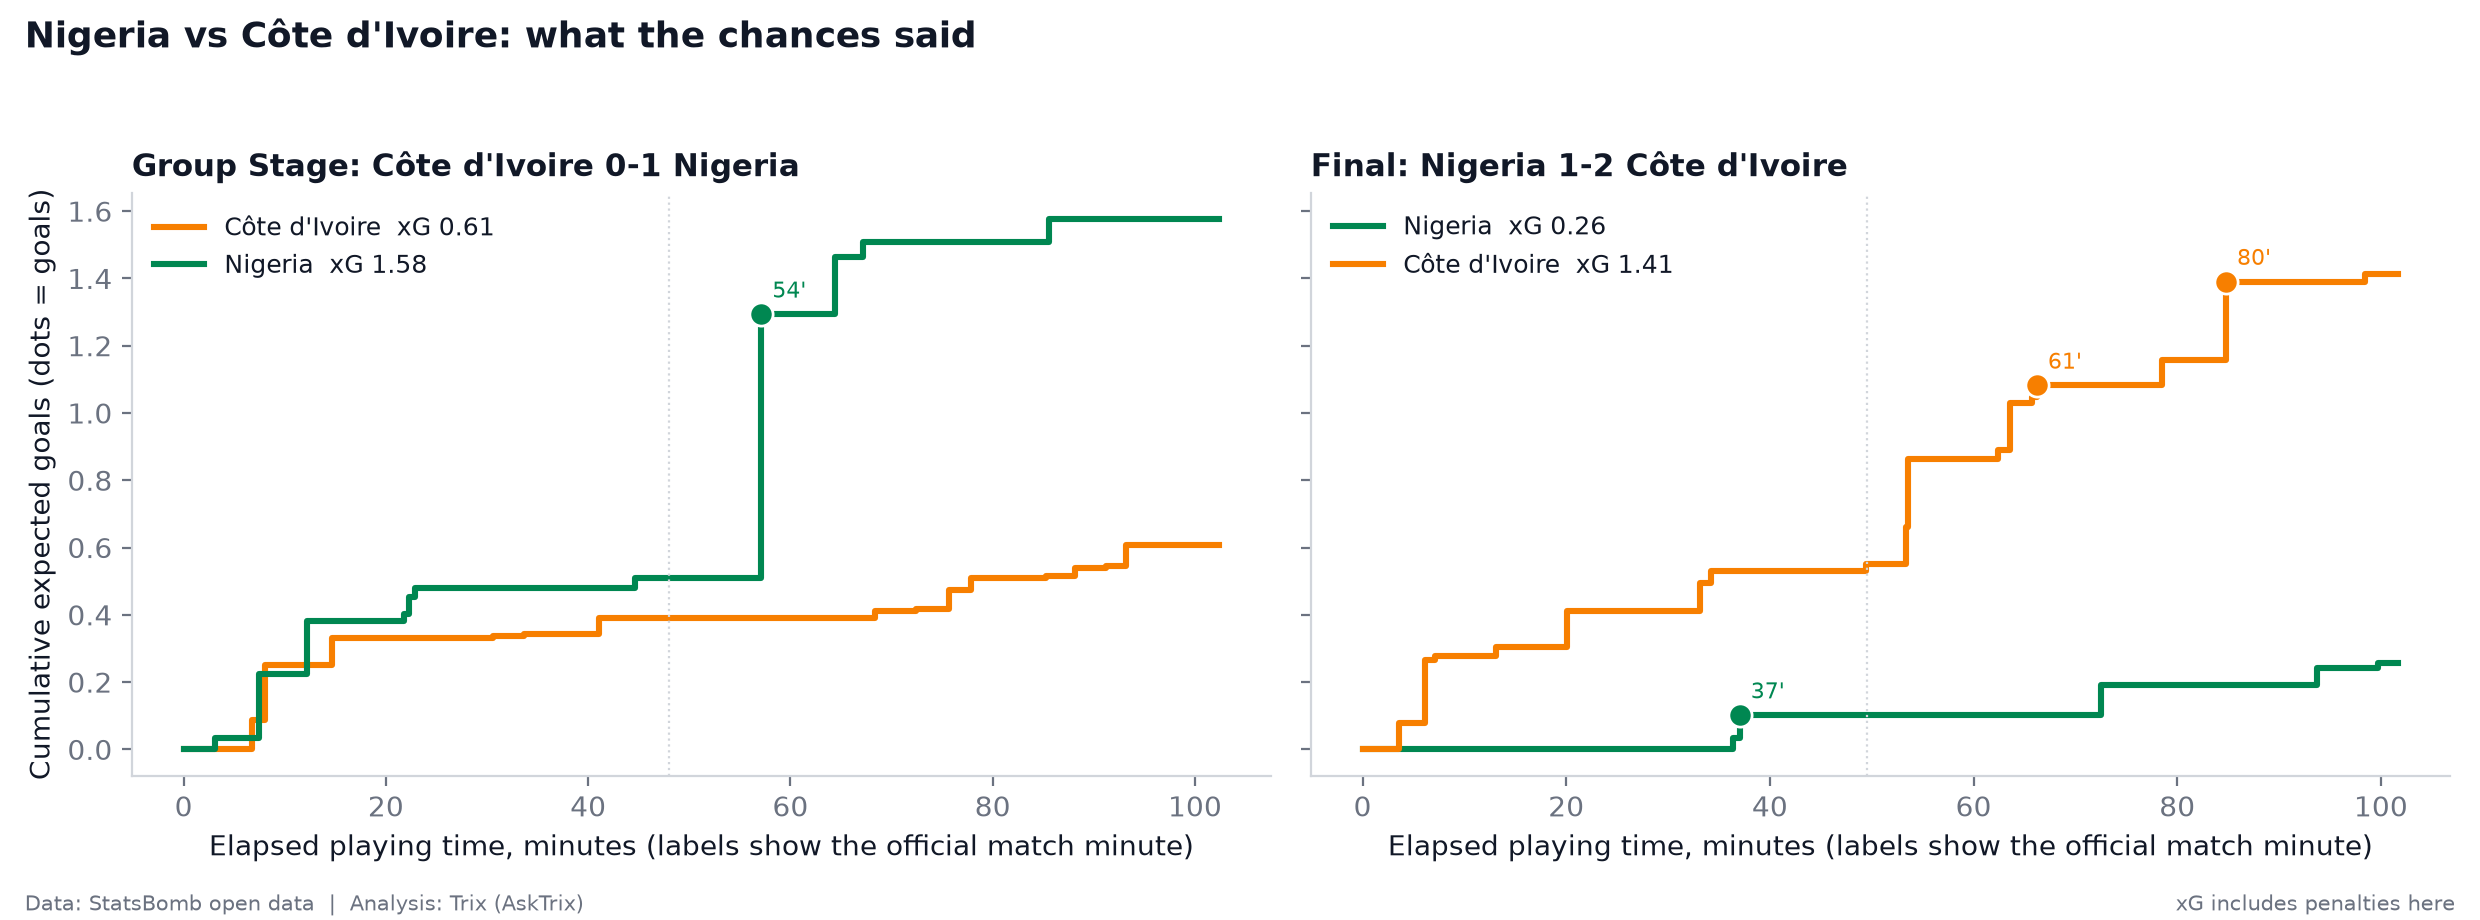

02_nigeria_vs_rival_shot_maps.png


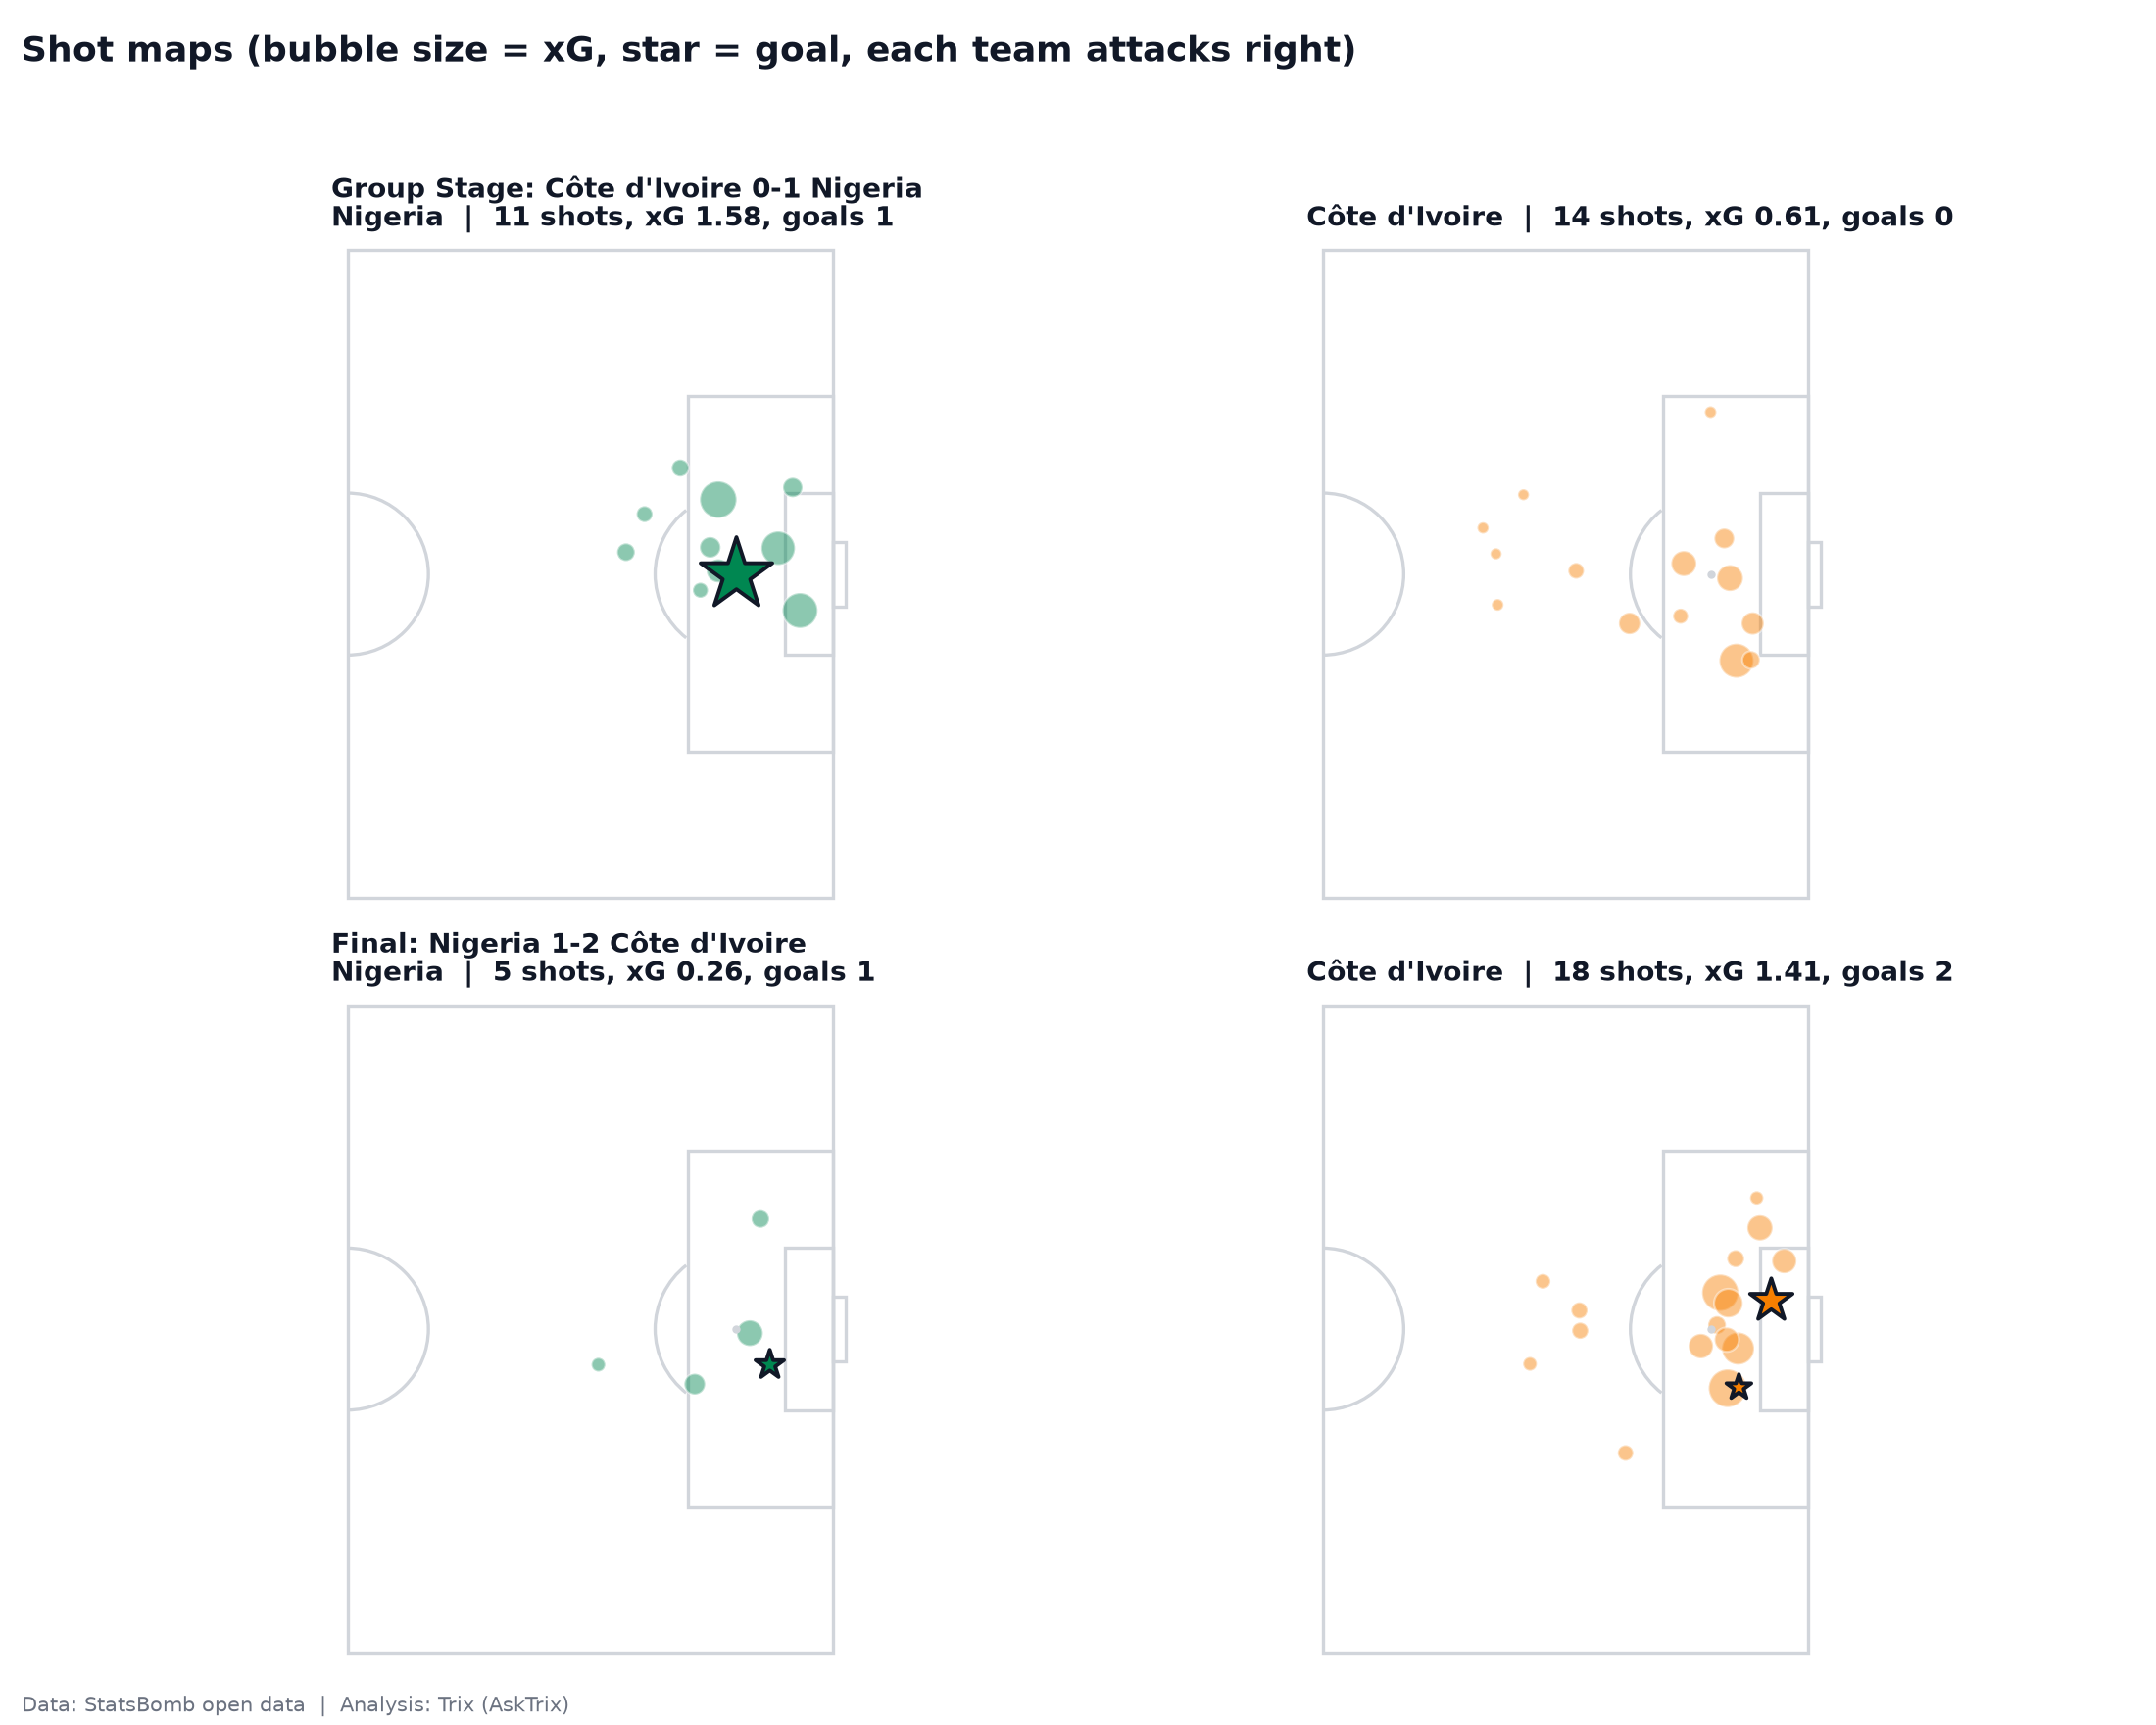

03_team_finishing_funnel.png


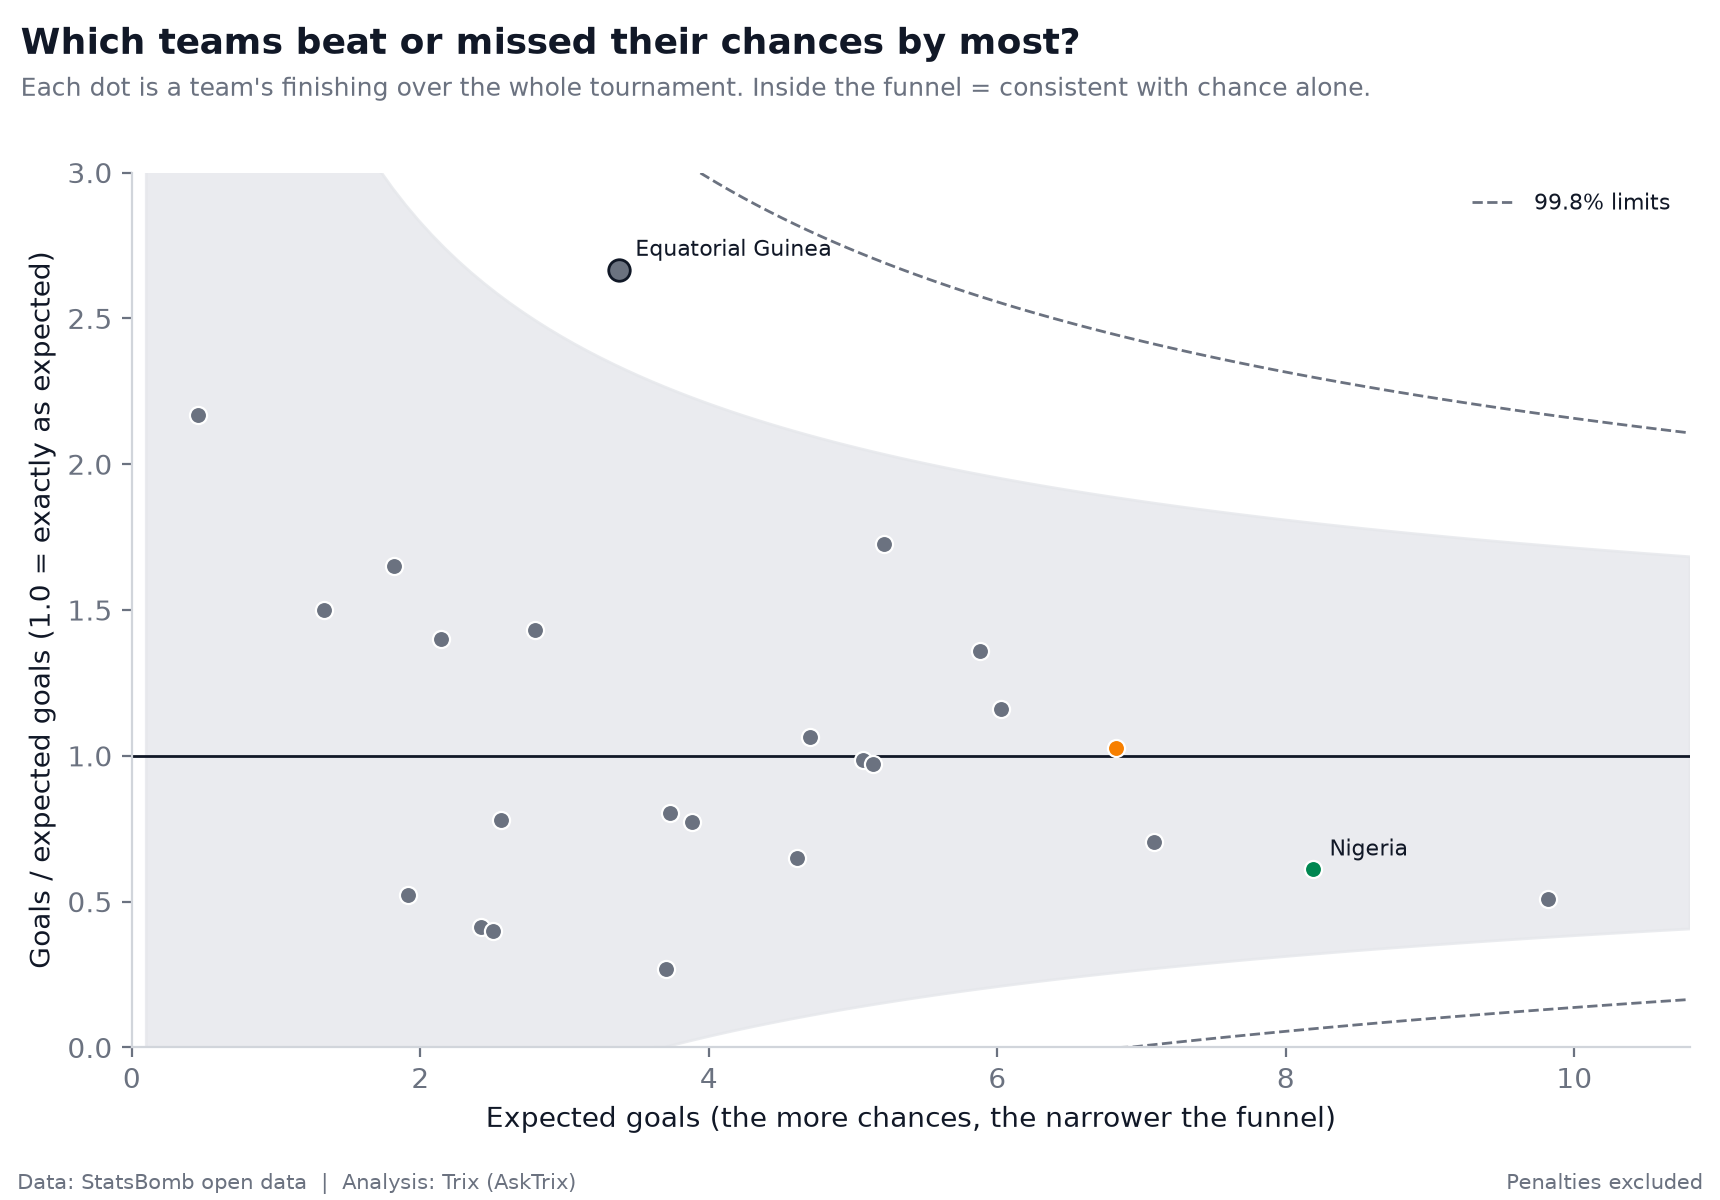

04_player_finishing_funnel.png


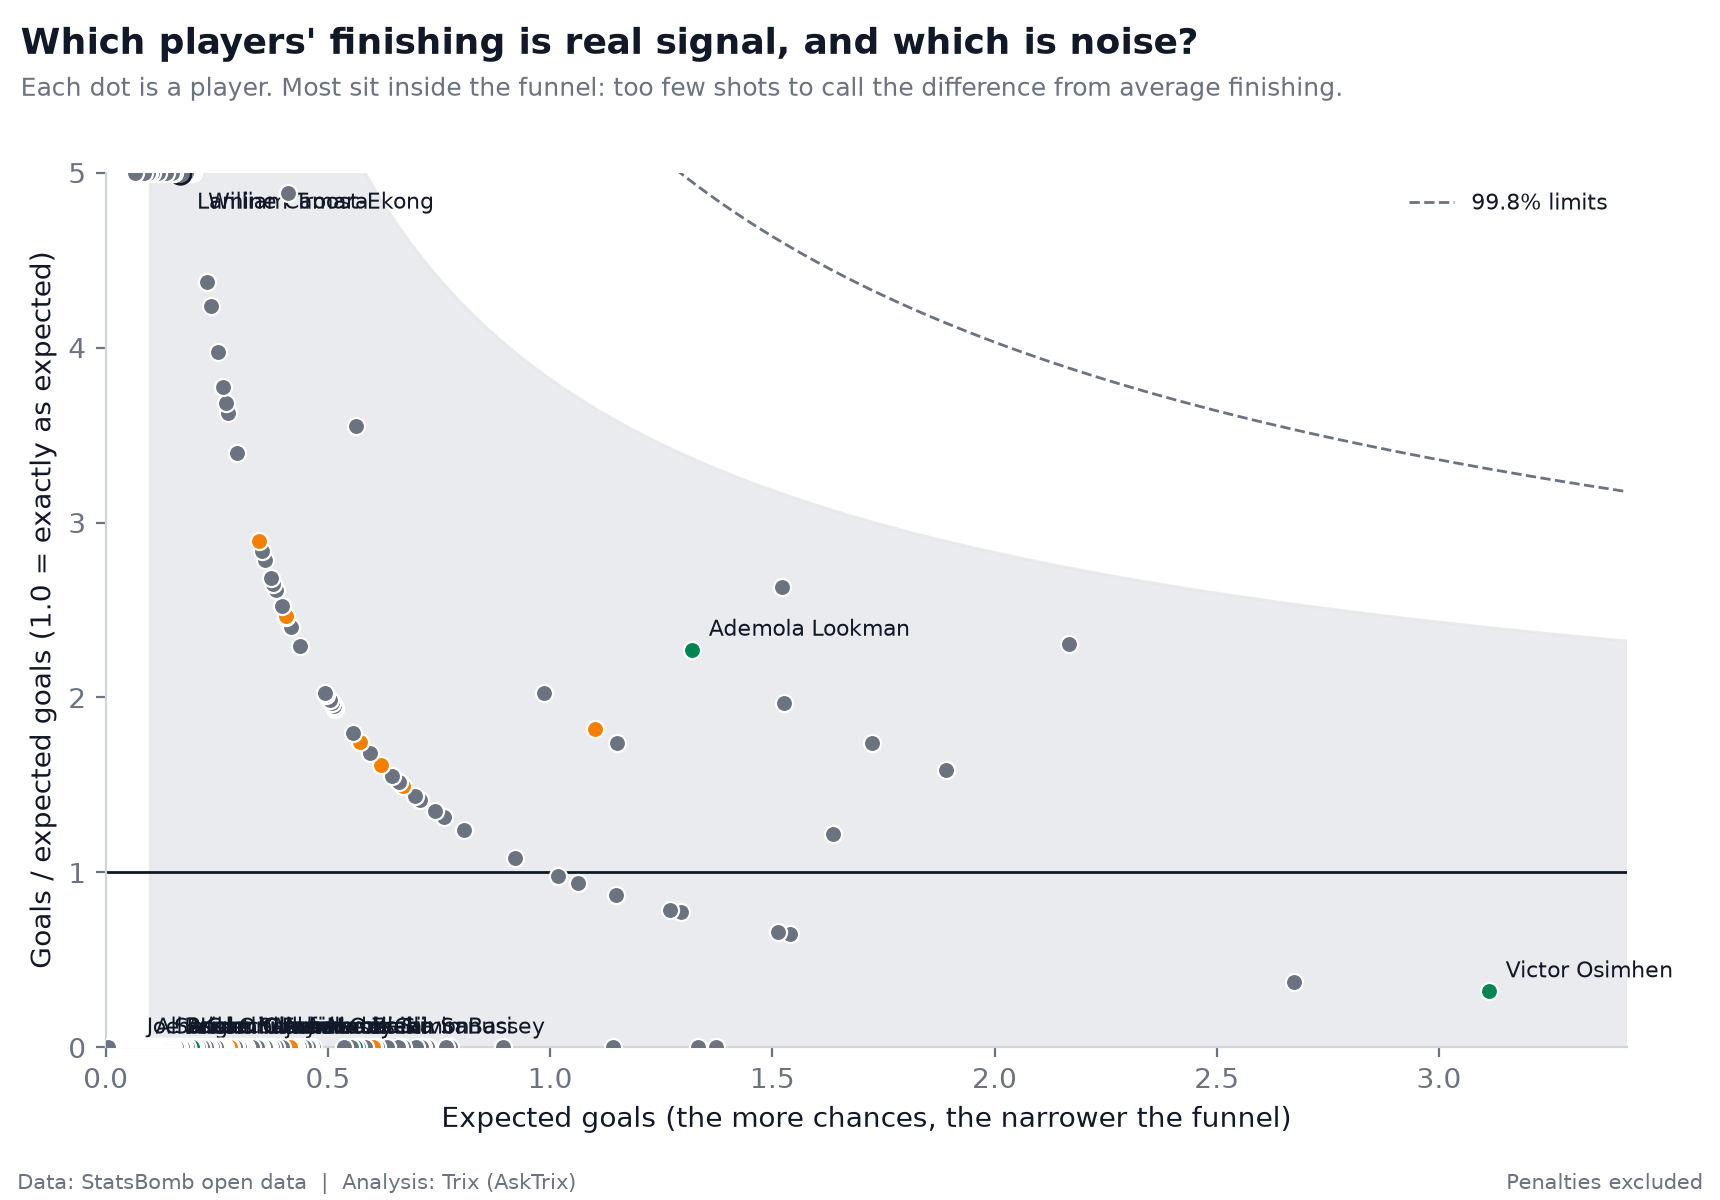

05_top_players_finishing_forest.png


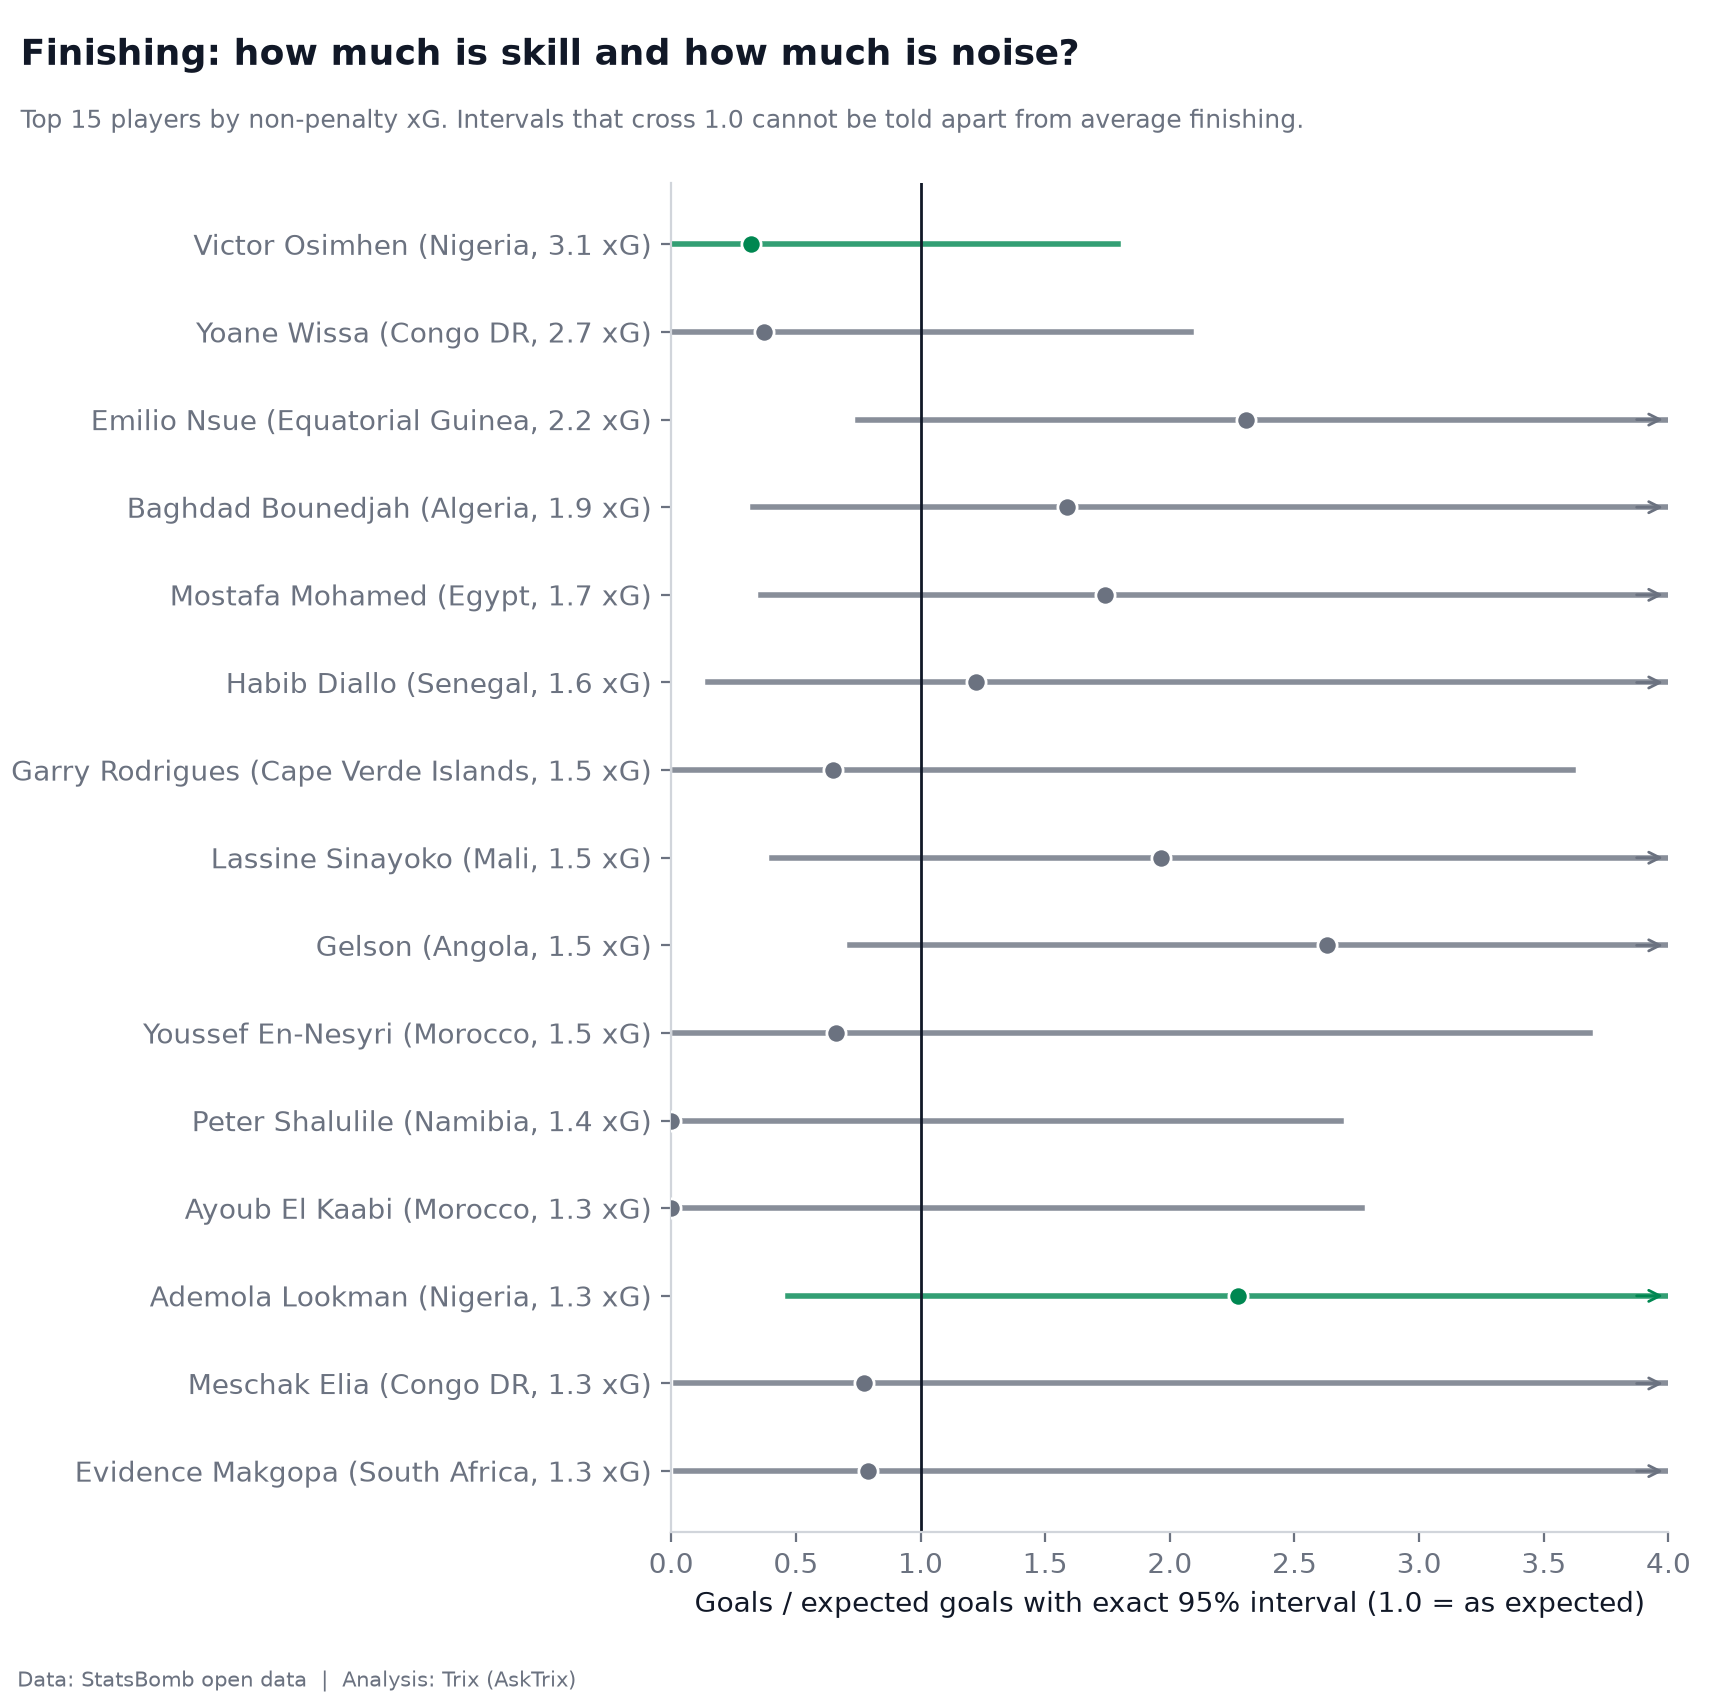

06_shot_involvement_per90.png


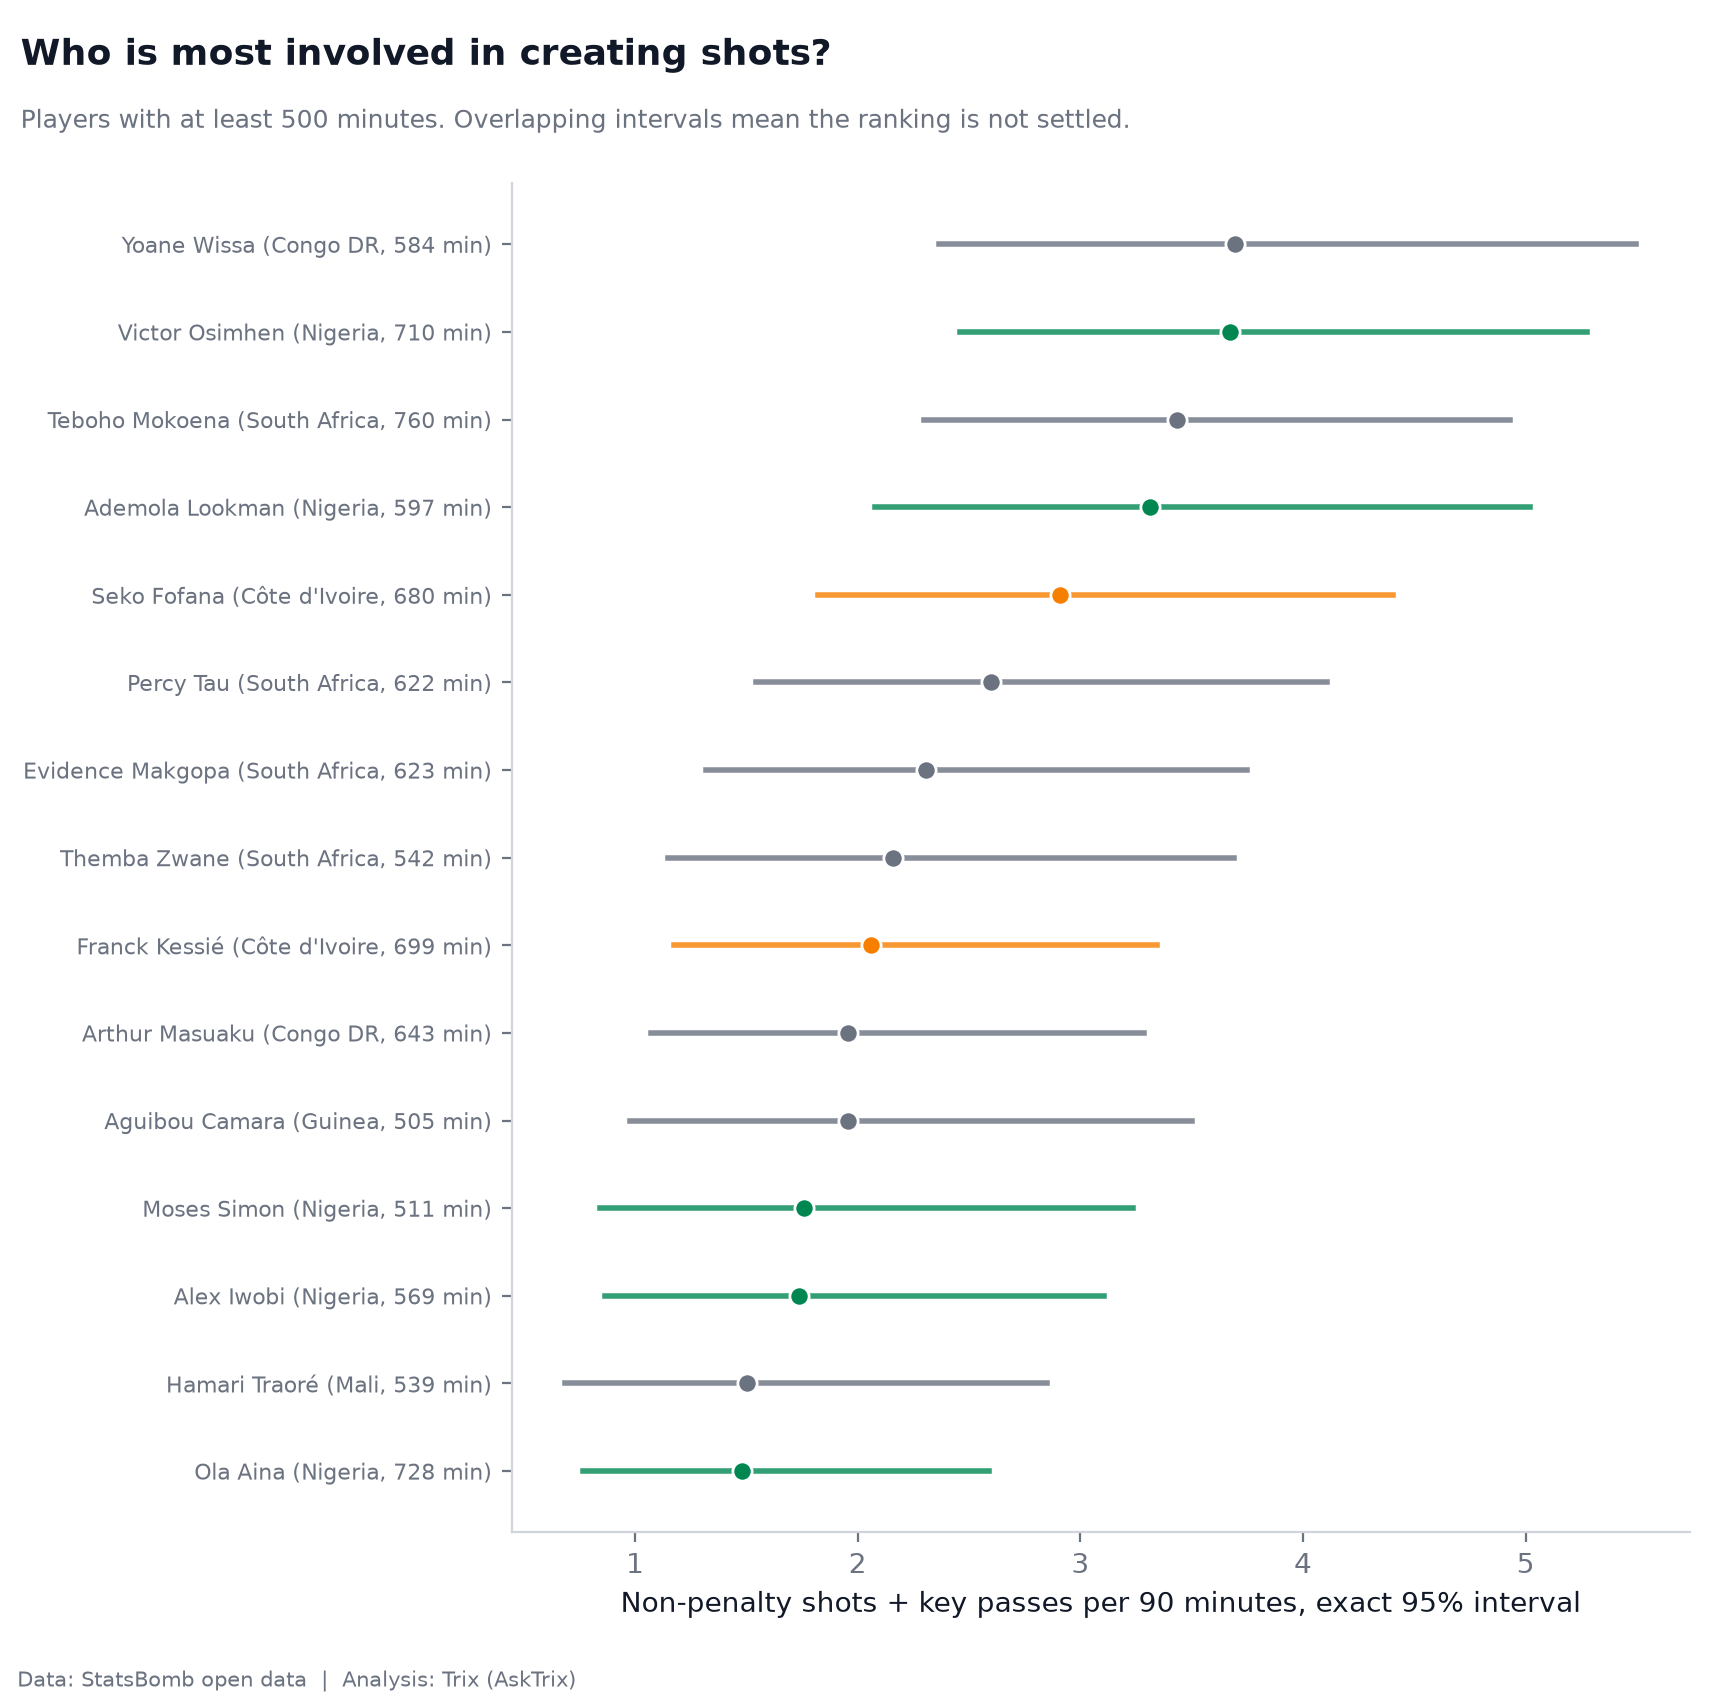

07_nigeria_results_vs_chances.png


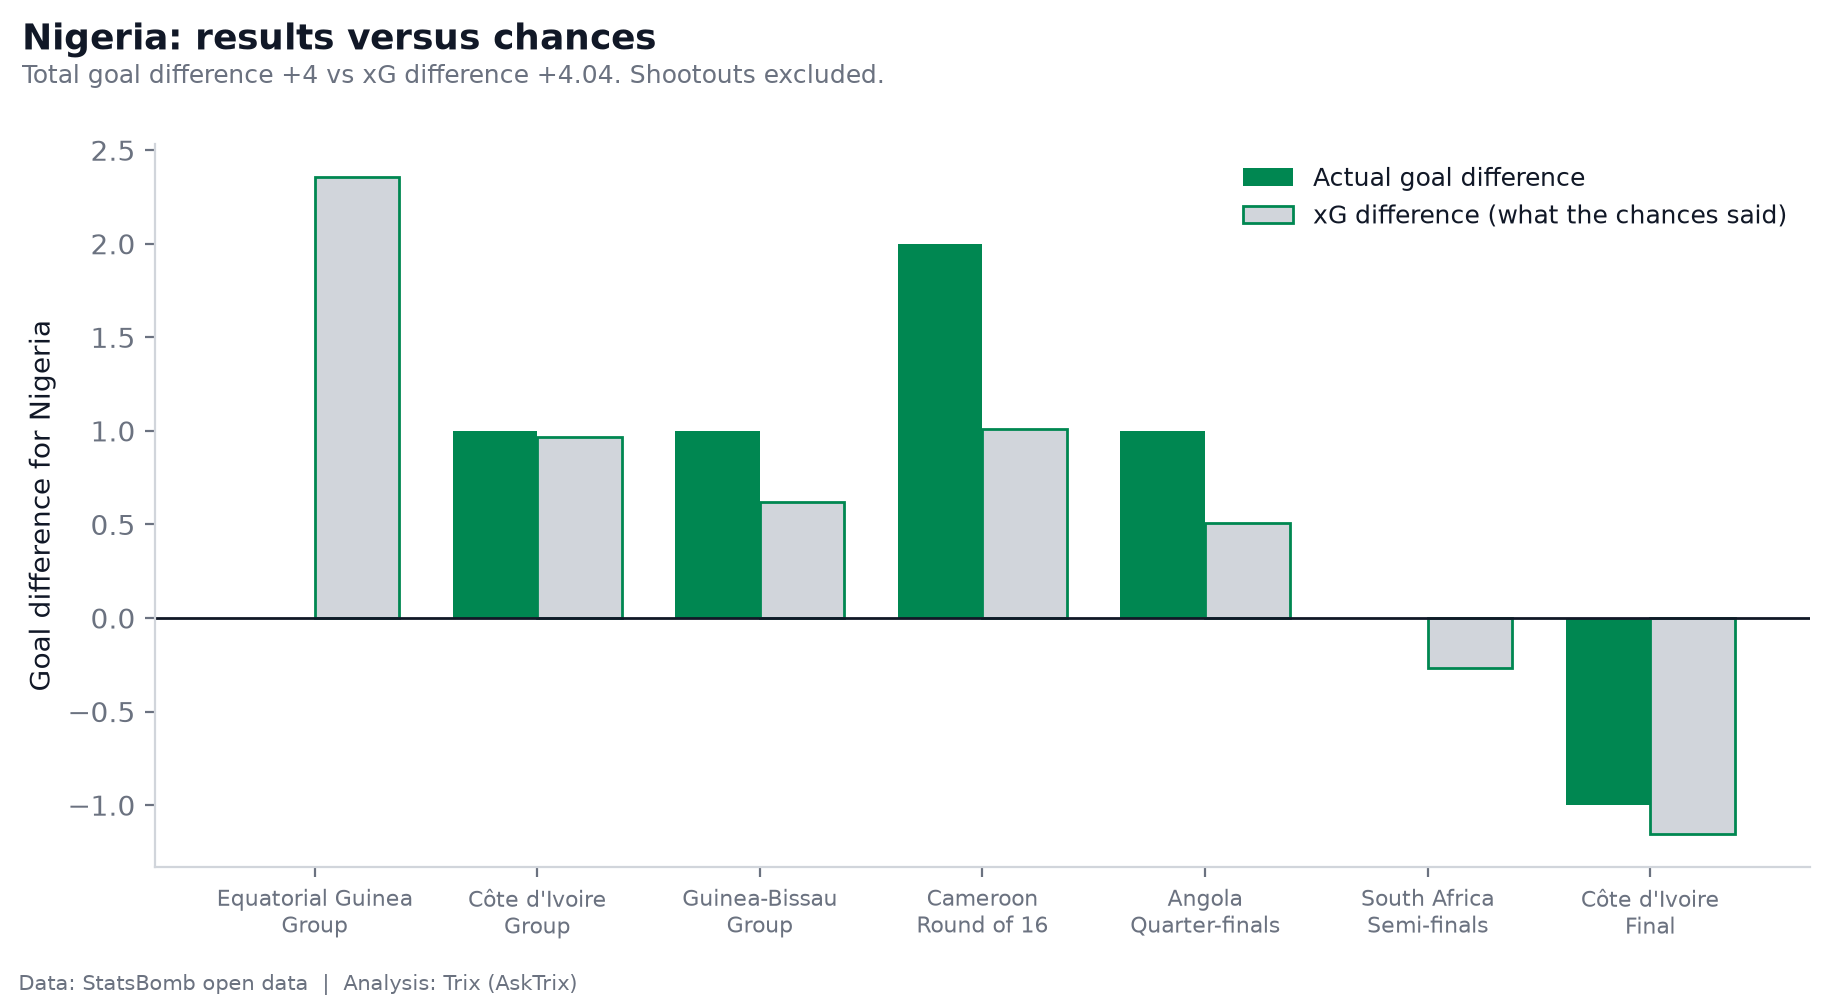

In [66]:
from IPython.display import display, Image
from pathlib import Path

for p in sorted(CHART_DIR.glob("*.png")):
    print(p.name)
    display(Image(filename=str(p)))